In [42]:
import os
import pickle
import optuna
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX
from datetime import datetime
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
from sklearn.inspection import permutation_importance as perm_imp
from xgboost import XGBRegressor

## Parâmetros Globais

Todos os parâmetros configuráveis do pipeline (datas de corte, limiares, espaços de busca, etc.) ficam centralizados nesta célula. Alterar o comportamento do notebook deve, na maioria dos casos, bastar editar valores aqui.

In [43]:
# --- Dados de entrada ---
PATH_TABELA_MESTRE = '../dados/gold/tabela_mestre.xlsx'
TARGET_COL = 'consumo_aparente'

# --- Diretório onde os resultados de cada execução são salvos ---
SECOES_DIR = './secoes/'

# --- Divisão temporal treino / val / teste ---
DATA_INICIO_VAL   = '2022-01-01'   # treino = tudo antes desta data
DATA_INICIO_TESTE = '2025-01-01'   # val = [DATA_INICIO_VAL, DATA_INICIO_TESTE); teste = a partir daqui

# --- Seleção de features ---
THRESHOLD_MULTICOLINEARIDADE = 0.90   # remove features com |corr| mútua acima disso
THRESHOLD_CORR_TARGET        = 0.05   # remove features com |corr| com o target abaixo disso

# --- Feature engineering ---
LAGS_CONSUMO        = [1, 2, 3]     # lags do target (meses)
LAGS_MACRO           = [1, 2, 3]     # lags das variáveis macro (meses)
COLS_MACRO           = ['taxa_selic_aa', 'ipca', 'pib_mensal']
JANELAS_MEDIA_MOVEL = [3, 6, 12]    # janelas das médias móveis (meses)

# --- Peso por recência (decaimento exponencial) ---
LAMBDA_FATOR = 0.95

# --- SARIMA / SARIMAX: espaço de busca do grid search por AIC ---
SARIMA_P, SARIMA_D, SARIMA_Q = [0, 1, 2], [1], [0, 1, 2]
SARIMA_SAZONAL_P, SARIMA_SAZONAL_D, SARIMA_SAZONAL_Q = [0, 1], [1], [0, 1]
SARIMA_S = 12   # periodicidade sazonal (mensal)

# --- XGBoost + Optuna ---
OPTUNA_N_TRIALS              = 50
OPTUNA_EARLY_STOPPING_ROUNDS = 20
WALK_FORWARD_N_SPLITS        = 8
WALK_FORWARD_TEST_SIZE       = 6

# --- Previsão futura (recursive multi-step forecasting) ---
N_HORIZONS            = 12   # meses à frente a prever
JANELA_PLOT_HISTORICO = 36   # meses de histórico exibidos no gráfico de previsão futura

In [44]:
datetime_str = datetime.strftime(datetime.now(), '%Y-%m-%d_%H-%M-%S')
os.makedirs(SECOES_DIR, exist_ok=True)
os.makedirs(f'{SECOES_DIR}resultados_{datetime_str}', exist_ok=True)
path_secao_atual = f'{SECOES_DIR}resultados_{datetime_str}'
print(f'Resultados serão salvos em: {path_secao_atual}')

Resultados serão salvos em: ./secoes/resultados_2026-07-01_17-10-01


In [45]:
pd.set_option('display.max_columns', None)

In [46]:
df_tabela_mestre = pd.read_excel(PATH_TABELA_MESTRE, engine='openpyxl')

In [47]:
df_tabela_mestre.head()

,data,consumo_aparente,anfavea_producao_autoveiculos_total,anfavea_producao_automoveis,anfavea_producao_comerciais_leves,anfavea_producao_caminhoes,anfavea_producao_onibus,anfavea_producao_total,ipca,pib_mensal,operacoes_credito_industria_construcao,operacoes_credito_industria_infraestrutura,operacoes_credito_industria_metalurgia_siderurgia,cno_outras_unidades,cno_km,cno_kva,cno_kw,cno_m2,cno_m3,valor_cambio_reais,taxa_selic_aa,ipp_metalurgia,ipp_fab_produtos_metal,ipp_fab_maq_apar_mat_eletricos,ipp_fab_maq_equip,ipp_fab_veic_reboque_carroceria,ipp_fab_outros_equip_transporte,pim_metalurgia,pim_fab_maq_equip,pim_fab_veic_reboque_carroceria,pim_fab_outros_equip_transporte,pnad_taxa_ocupacao,custo_projeto_m2
0,2013-01-01,905.896,291884,237700,38430,12622,3132,583768,0.86,408895.0,93691,23988,47137,226535.31,1318.93,0.0,0.00,6256607.14,57915.94,1.440984,7.442417,71.51497,77.06881,76.65715,81.08439,77.66284,62.19166,1598.927,660.4378,967.89891,1304.52774,58.5,1822703.31
1,2013-02-01,874.438,242072,191832,33564,13664,3012,484144,0.60,398087.4,94316,24318,47802,2375468.83,35356.44,300.0,0.00,3585060.38,202427.96,1.268150,6.041083,71.51497,77.06881,76.65715,81.08439,77.66284,62.19166,1598.927,660.4378,967.89891,1304.52774,58.5,1822703.31
2,2013-03-01,1018.972,329103,265001,43782,16533,3787,658206,0.47,434631.2,96662,24734,48433,37550.53,151.27,0.0,143845.00,3590771.35,296.10,1.278884,6.803356,71.51497,77.06881,76.65715,81.08439,77.66284,62.19166,1598.927,660.4378,967.89891,1304.52774,58.5,1822703.31
3,2013-04-01,1035.119,352328,278924,51538,18034,3832,704656,0.55,446508.1,97451,24901,48442,86607783.93,18317.29,0.0,56.24,4193890.04,21194.45,1.467863,7.570649,71.51497,77.06881,76.65715,81.08439,77.66284,62.19166,1598.927,660.4378,967.89891,1304.52774,58.5,1822703.31
4,2013-05-01,1053.642,344556,275799,48491,16378,3888,689112,0.37,441321.9,99717,25191,48803,616190.93,1561.29,0.0,117.06,4526387.72,48913.61,1.378052,7.442417,71.51497,77.06881,76.65715,81.08439,77.66284,62.19166,1598.927,660.4378,967.89891,1304.52774,58.5,1822703.31


In [48]:
df_tabela_mestre.shape

(161, 33)

## 1. Análise Exploratória (EDA)

Colunas com valores nulos (%):
Series([], dtype: float64)


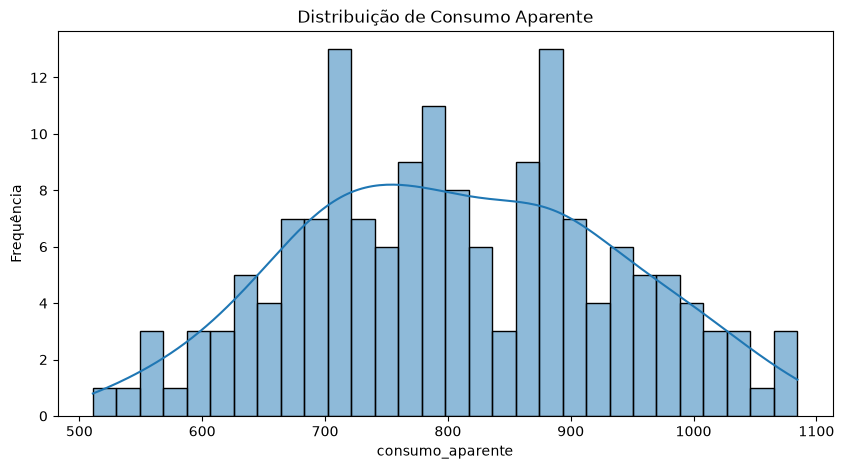

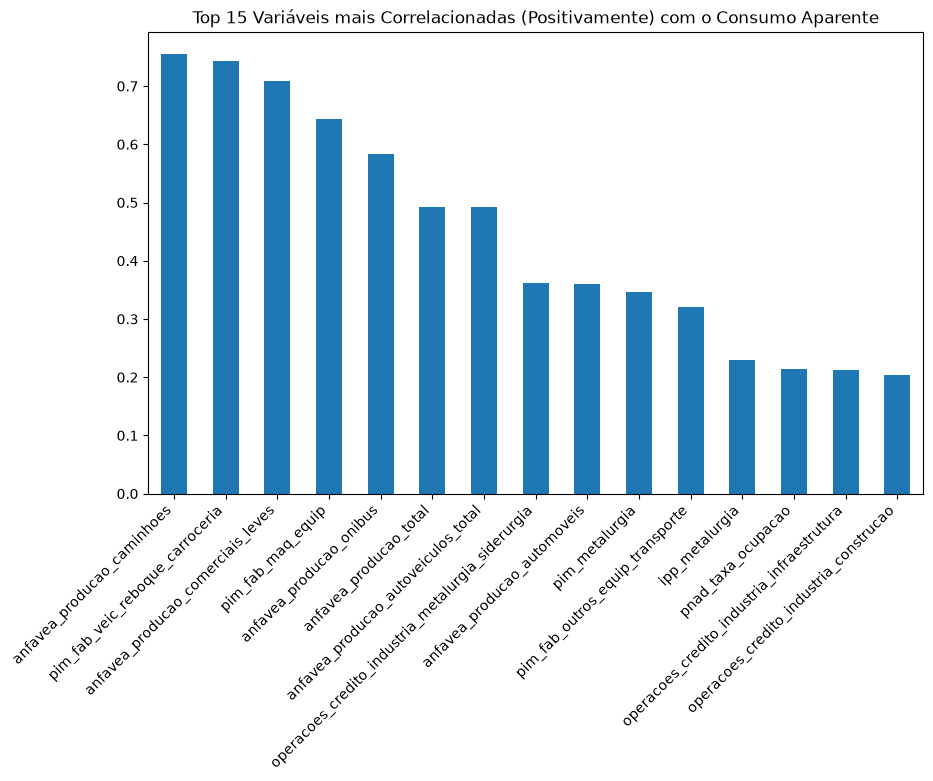

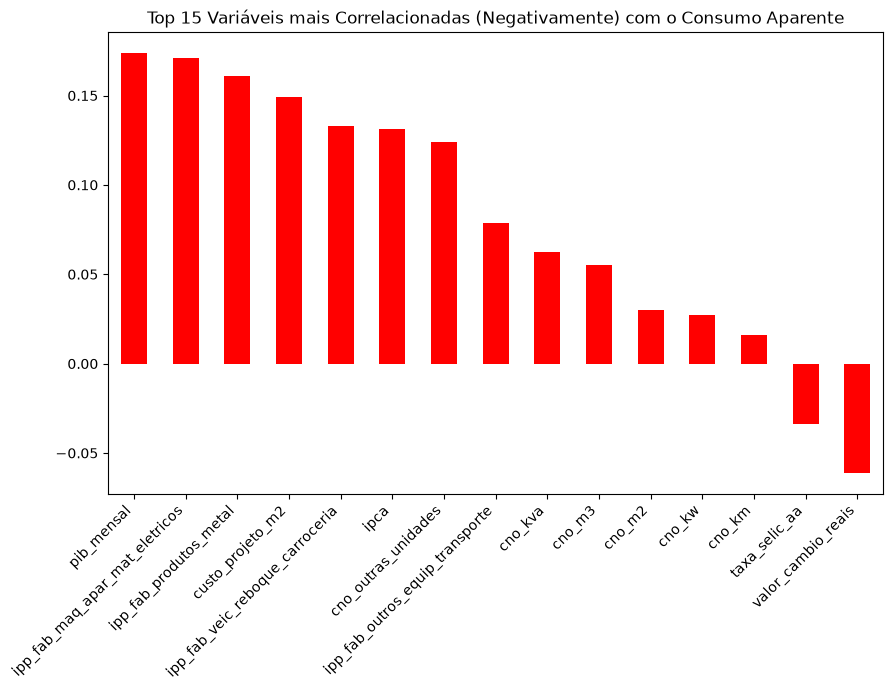

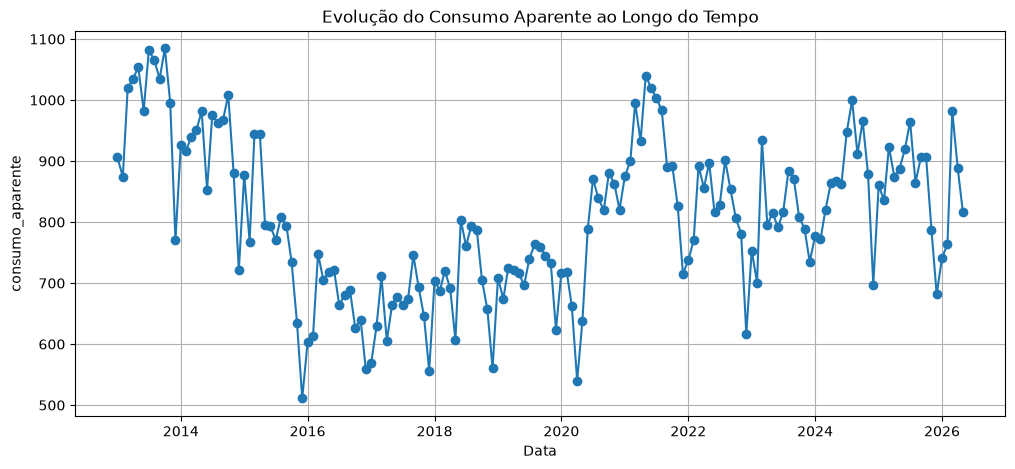

In [49]:
# Remover colunas com mais de 50% de nulos caso existam, ou apenas visualizar
missing = df_tabela_mestre.isnull().mean() * 100
print("Colunas com valores nulos (%):")
print(missing[missing > 0].sort_values(ascending=False))

# Distribuição da Variável Target
plt.figure(figsize=(10, 5))
sns.histplot(df_tabela_mestre['consumo_aparente'], kde=True, bins=30)
plt.title('Distribuição de Consumo Aparente')
plt.xlabel('consumo_aparente')
plt.ylabel('Frequência')
plt.show()

# Correlação com a variável Target (top 15)
numeric_df = df_tabela_mestre.select_dtypes(include=[np.number])
correlations = numeric_df.corr()['consumo_aparente'].sort_values(ascending=False)
plt.figure(figsize=(10, 6))
correlations.drop('consumo_aparente').head(15).plot(kind='bar')
plt.title('Top 15 Variáveis mais Correlacionadas (Positivamente) com o Consumo Aparente')
plt.xticks(rotation=45, ha='right')
plt.show()

# Correlações Negativas (top 15)
plt.figure(figsize=(10, 6))
correlations.tail(15).plot(kind='bar', color='red')
plt.title('Top 15 Variáveis mais Correlacionadas (Negativamente) com o Consumo Aparente')
plt.xticks(rotation=45, ha='right')
plt.show()

# Evolução do Consumo ao longo do tempo (se aplicável)
if 'data' in df_tabela_mestre.columns:
    df_temp = df_tabela_mestre.copy()
    df_temp['data'] = pd.to_datetime(df_temp['data'])
    df_temp.sort_values('data', inplace=True)
    
    plt.figure(figsize=(12, 5))
    plt.plot(df_temp['data'], df_temp['consumo_aparente'], marker='o', linestyle='-')
    plt.title('Evolução do Consumo Aparente ao Longo do Tempo')
    plt.xlabel('Data')
    plt.ylabel('consumo_aparente')
    plt.grid(True)
    plt.show()


## Remoção de Variáveis Muito Correlacionadas (Multicolinearidade)

In [50]:
# Removeremos a variável target da verificação para garantir que ela não seja removida
numeric_cols = df_tabela_mestre.select_dtypes(include=[np.number]).columns.tolist()
if TARGET_COL in numeric_cols:
    numeric_cols.remove(TARGET_COL)

# Calcular matriz de correlação absoluta
corr_matrix = df_tabela_mestre[numeric_cols].corr().abs()

# Obter triângulo superior da matriz de correlação
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Identificar variáveis com correlação superior ao limiar de multicolinearidade
threshold = THRESHOLD_MULTICOLINEARIDADE
to_drop = [column for column in upper.columns if any(upper[column] > threshold)]

print(f"Variáveis muito correlacionadas a serem removidas ({len(to_drop)}):")
for col in to_drop:
    print(f" - {col}")

# Remover as colunas identificadas
df_tabela_mestre = df_tabela_mestre.drop(columns=to_drop)

print("\nShape do dataset após remoção das variáveis correlacionadas:", df_tabela_mestre.shape)

Variáveis muito correlacionadas a serem removidas (10):
 - anfavea_producao_automoveis
 - anfavea_producao_total
 - operacoes_credito_industria_infraestrutura
 - ipp_metalurgia
 - ipp_fab_produtos_metal
 - ipp_fab_maq_apar_mat_eletricos
 - ipp_fab_maq_equip
 - ipp_fab_veic_reboque_carroceria
 - ipp_fab_outros_equip_transporte
 - custo_projeto_m2

Shape do dataset após remoção das variáveis correlacionadas: (161, 23)


## Visualização das Séries Temporais Disponíveis

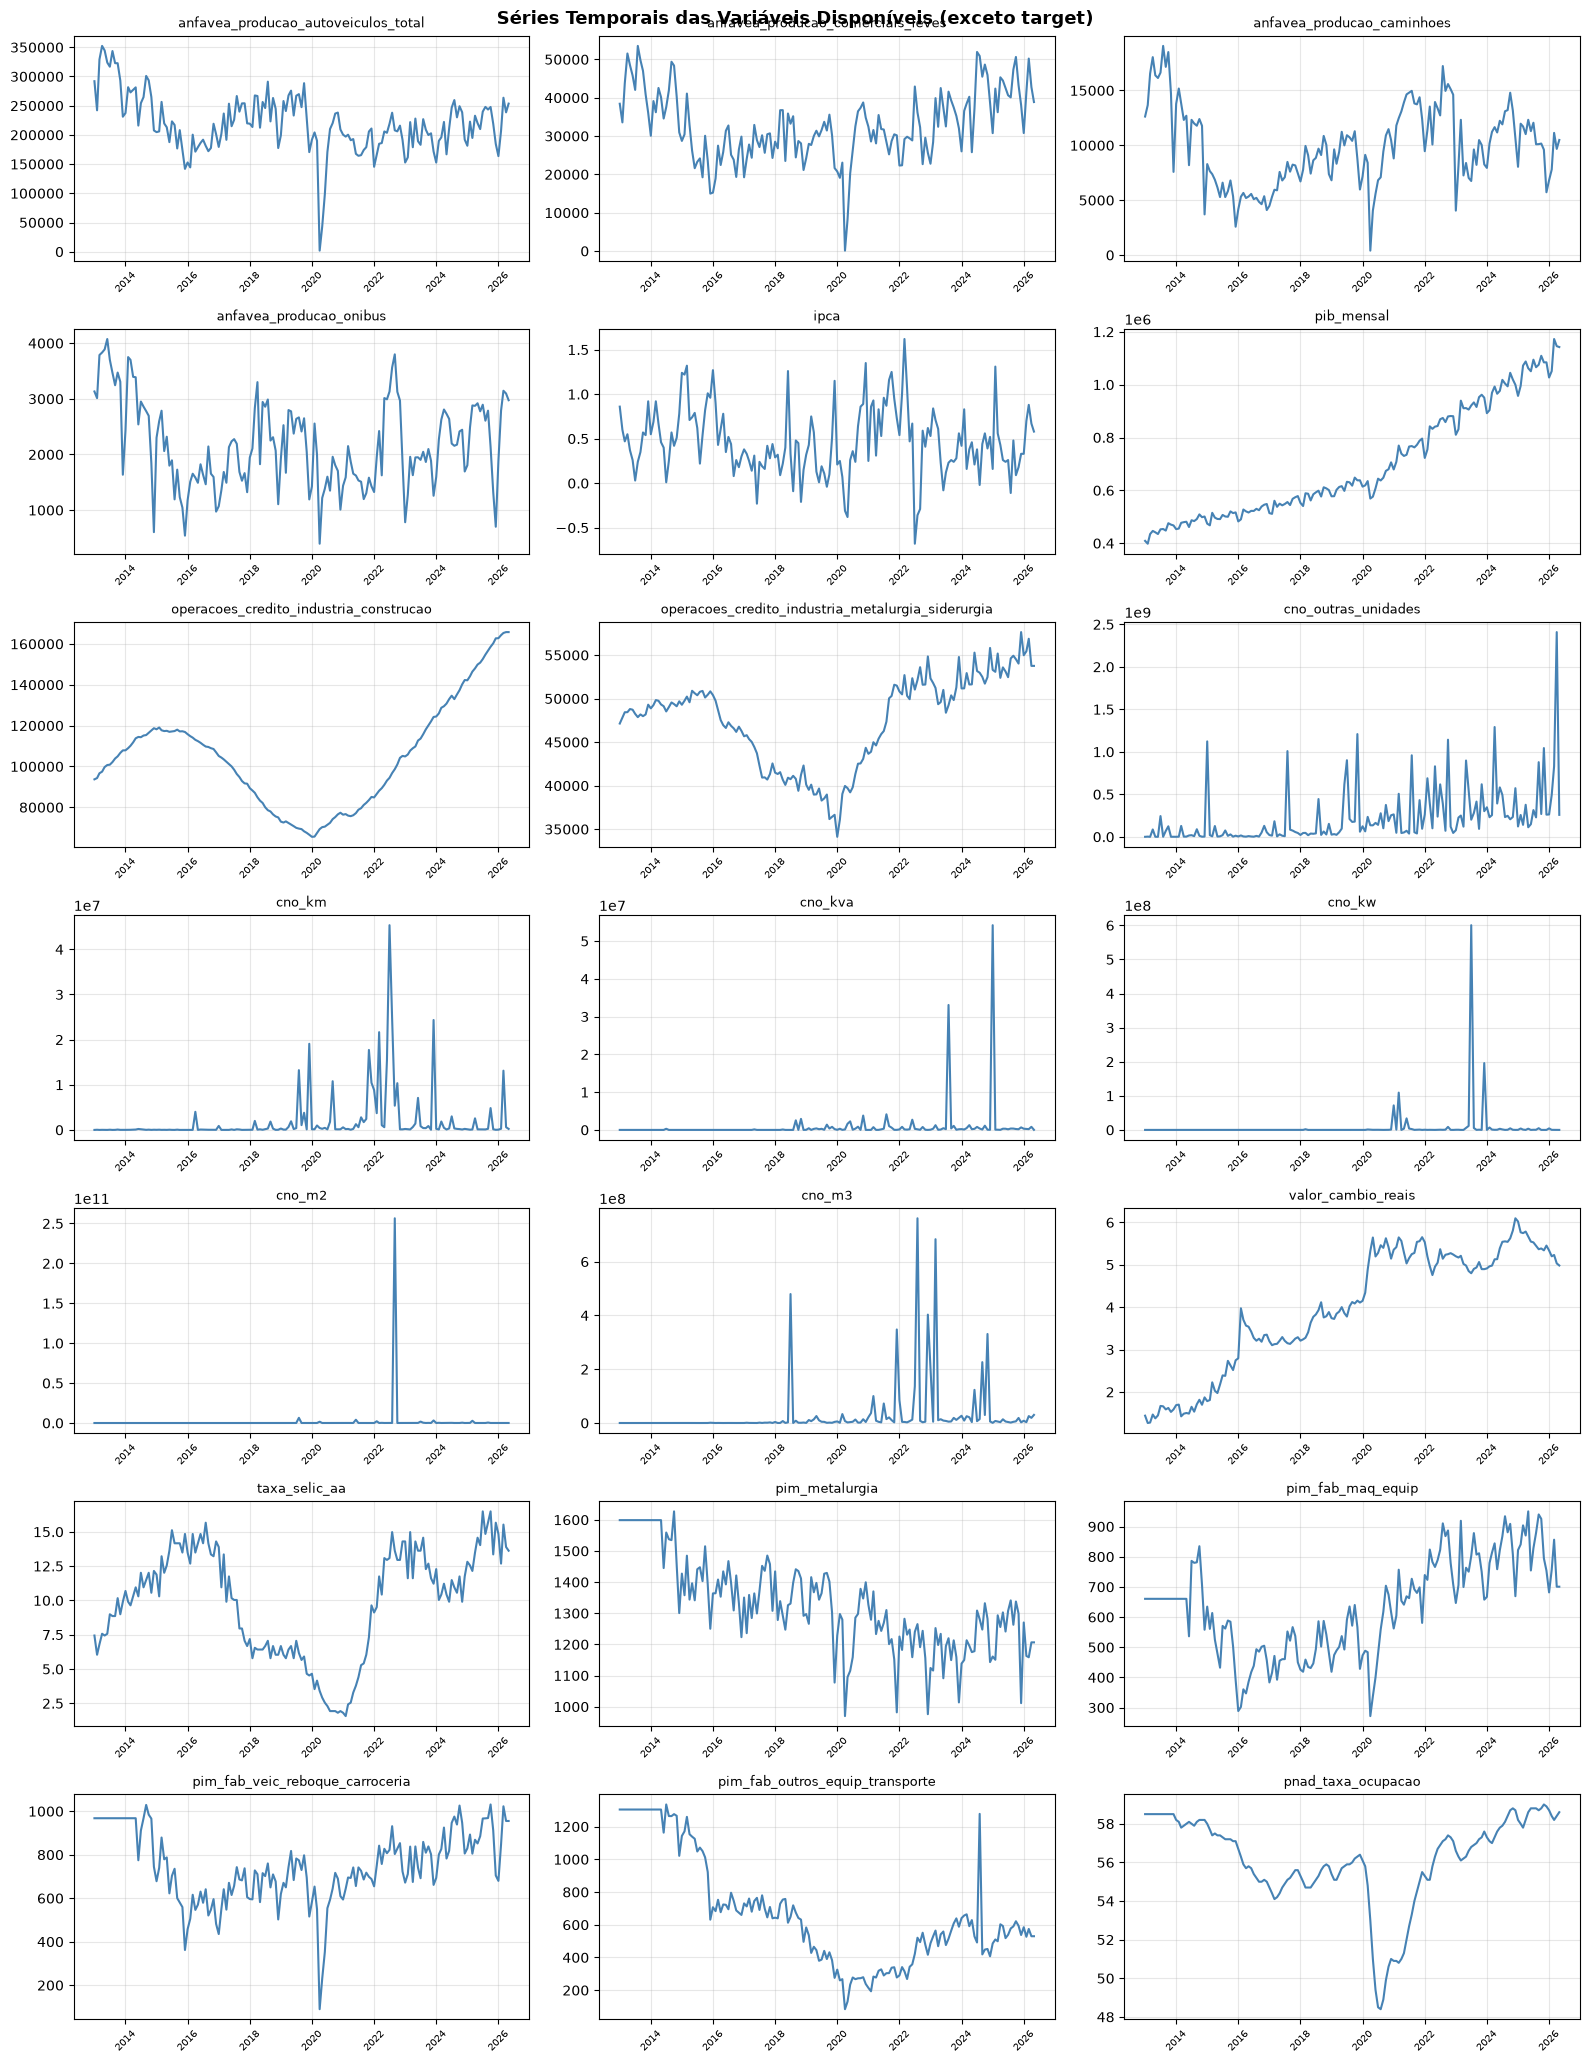

In [51]:
# Todas as séries temporais restantes após remoção de multicolinearidade, exceto o target (já plotado na EDA)
plot_cols = [c for c in df_tabela_mestre.columns if c not in ['data', TARGET_COL]]

n_por_linha = 3
n_linhas = int(np.ceil(len(plot_cols) / n_por_linha))

fig, axes = plt.subplots(n_linhas, n_por_linha, figsize=(16, n_linhas * 3))
axes = axes.flatten()

for ax, col in zip(axes, plot_cols):
    ax.plot(df_tabela_mestre['data'], df_tabela_mestre[col], color='steelblue')
    ax.set_title(col, fontsize=9)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.grid(alpha=0.3)

# Desliga os eixos sobrando quando o grid é maior que o número de variáveis
for ax in axes[len(plot_cols):]:
    ax.axis('off')

fig.suptitle('Séries Temporais das Variáveis Disponíveis (exceto target)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Feature Engineering: Lags, Médias Móveis e Codificação Cíclica do Mês

In [52]:
df_tabela_mestre = df_tabela_mestre.sort_values('data').reset_index(drop=True)

# Lags do target — shift garante que não há look-ahead
for lag in LAGS_CONSUMO:
    df_tabela_mestre[f'consumo_lag_{lag}'] = df_tabela_mestre[TARGET_COL].shift(lag)

# Lags das variáveis macro — mesmo racional do target (shift evita look-ahead)
for col in COLS_MACRO:
    if col in df_tabela_mestre.columns:
        for lag in LAGS_MACRO:
            df_tabela_mestre[f'{col}_lag_{lag}'] = df_tabela_mestre[col].shift(lag)

# Médias móveis — shift(1) antes do rolling evita usar o valor corrente
for janela in JANELAS_MEDIA_MOVEL:
    df_tabela_mestre[f'consumo_ma{janela}'] = df_tabela_mestre[TARGET_COL].shift(1).rolling(janela).mean()

# Codificação cíclica do mês (sin/cos em vez de inteiro 1-12)
# Inteiro bruto implica que dezembro (12) > janeiro (1), quebrando a ciclicidade
df_tabela_mestre['mes_sin'] = np.sin(2 * np.pi * df_tabela_mestre['data'].dt.month / 12)
df_tabela_mestre['mes_cos'] = np.cos(2 * np.pi * df_tabela_mestre['data'].dt.month / 12)

# Trend linear substitui 'ano' bruto, que extrapolaria mal fora do range de treino
df_tabela_mestre['trend'] = range(len(df_tabela_mestre))

# Remover linhas com NaN gerados pelos lags (primeiros meses)
df_tabela_mestre = df_tabela_mestre.dropna().reset_index(drop=True)
print(f"Shape após feature engineering: {df_tabela_mestre.shape}")
print(f"Histórico de dados disponível: {df_tabela_mestre['data'].min().date()} → {df_tabela_mestre['data'].max().date()}")

Shape após feature engineering: (149, 41)
Histórico de dados disponível: 2014-01-01 → 2026-05-01


## Seleção de Features — Etapa 1: Filtro de Correlação

In [53]:
df_tabela_mestre.head()

,data,consumo_aparente,anfavea_producao_autoveiculos_total,anfavea_producao_comerciais_leves,anfavea_producao_caminhoes,anfavea_producao_onibus,ipca,pib_mensal,operacoes_credito_industria_construcao,operacoes_credito_industria_metalurgia_siderurgia,cno_outras_unidades,cno_km,cno_kva,cno_kw,cno_m2,cno_m3,valor_cambio_reais,taxa_selic_aa,pim_metalurgia,pim_fab_maq_equip,pim_fab_veic_reboque_carroceria,pim_fab_outros_equip_transporte,pnad_taxa_ocupacao,consumo_lag_1,consumo_lag_2,consumo_lag_3,taxa_selic_aa_lag_1,taxa_selic_aa_lag_2,taxa_selic_aa_lag_3,ipca_lag_1,ipca_lag_2,ipca_lag_3,pib_mensal_lag_1,pib_mensal_lag_2,pib_mensal_lag_3,consumo_ma3,consumo_ma6,consumo_ma12,mes_sin,mes_cos,trend
0,2014-01-01,927.046,237390,30088,13776,2431,0.55,453274.2,107896,48880,5.273980e+05,13224.64,150.0,0.00,7793517.45,67046.35,1.690171,10.690623,1598.927,660.4378,967.89891,1304.52774,58.2,769.865,995.462,1084.536,9.902948,8.990490,10.164934,0.92,0.54,0.57,467254.2,470316.1,475720.9,949.954333,1005.247667,991.862417,0.500000,8.660254e-01,12
1,2014-02-01,916.842,281627,39125,15174,3750,0.69,455505.4,108950,49258,1.882174e+06,12370.35,0.0,60000.00,4172578.38,14043.68,1.702207,9.902948,1598.927,660.4378,967.89891,1304.52774,58.1,927.046,769.865,995.462,10.690623,9.902948,8.990490,0.55,0.92,0.54,453274.2,467254.2,470316.1,897.457667,979.529833,993.624917,0.866025,5.000000e-01,13
2,2014-03-01,940.044,272754,36211,13844,3700,0.92,477201.5,110130,49832,1.281491e+08,27611.11,500.0,51050.17,3919601.95,341809.82,1.425303,9.641534,1598.927,660.4378,967.89891,1304.52774,57.8,916.842,927.046,769.865,9.902948,10.690623,9.902948,0.69,0.55,0.92,455505.4,453274.2,467254.2,871.251000,954.759500,997.158583,1.000000,6.123234e-17,14
3,2014-04-01,951.105,277091,42551,12314,3395,0.67,479725.1,111799,49751,2.380034e+06,63868.05,0.0,56000.00,5182198.92,30289.10,1.488117,10.296141,1598.927,660.4378,967.89891,1304.52774,57.9,940.044,916.842,927.046,9.641534,9.902948,10.690623,0.92,0.69,0.55,477201.5,455505.4,453274.2,927.977333,938.965833,990.581250,0.866025,-5.000000e-01,15
4,2014-05-01,981.738,281355,40144,12695,3388,0.46,481271.5,113783,49331,2.394161e+06,79957.55,0.0,0.00,5714652.20,308819.95,1.504061,10.954329,1598.927,660.4378,967.89891,1304.52774,58.0,951.105,940.044,916.842,10.296141,9.641534,9.902948,0.67,0.92,0.69,479725.1,477201.5,455505.4,935.997000,916.727333,983.580083,0.500000,-8.660254e-01,16


Removidas por |corr| < 0.05 (1):
  - pnad_taxa_ocupacao                                                      |corr| = 0.0394

Mantidas após filtro: 38
consumo_lag_1                                        0.783273
consumo_ma3                                          0.745379
consumo_ma6                                          0.705603
pim_fab_maq_equip                                    0.701099
pim_fab_veic_reboque_carroceria                      0.701033
consumo_lag_2                                        0.688262
anfavea_producao_caminhoes                           0.684768
consumo_ma12                                         0.666813
anfavea_producao_comerciais_leves                    0.647899
consumo_lag_3                                        0.572577
anfavea_producao_onibus                              0.431052
operacoes_credito_industria_metalurgia_siderurgia    0.359621
pib_mensal                                           0.324418
anfavea_producao_autoveiculos_total        

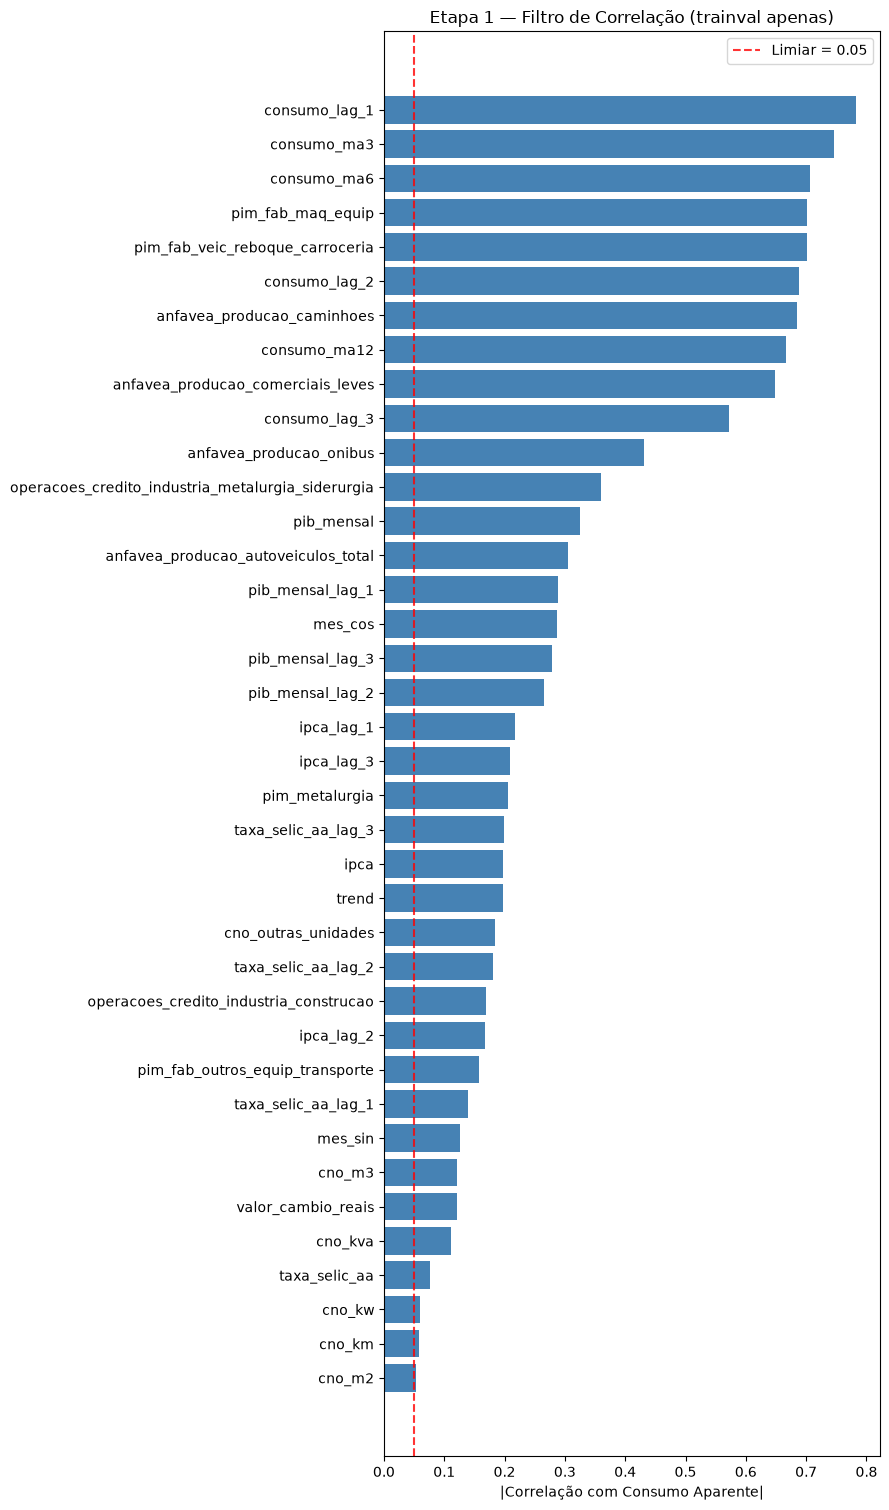

In [54]:
target_col = TARGET_COL

# Correlação computada apenas no trainval (< data de início do teste) — sem vazar informação do test
_df_tv = df_tabela_mestre[df_tabela_mestre['data'] < DATA_INICIO_TESTE].copy()
FEATURE_COLS_ALL = [c for c in _df_tv.columns if c not in ['data', target_col]]

corr_abs = _df_tv[FEATURE_COLS_ALL].corrwith(_df_tv[target_col]).abs().sort_values(ascending=False)

THRESHOLD_CORR = THRESHOLD_CORR_TARGET
features_drop_corr = corr_abs[corr_abs < THRESHOLD_CORR].index.tolist()
FEATURES_CORR      = corr_abs[corr_abs >= THRESHOLD_CORR].index.tolist()

print(f"Removidas por |corr| < {THRESHOLD_CORR} ({len(features_drop_corr)}):")
for f in features_drop_corr:
    print(f"  - {f:<70}  |corr| = {corr_abs[f]:.4f}")
print(f"\nMantidas após filtro: {len(FEATURES_CORR)}")
print(corr_abs[FEATURES_CORR].rename('|corr|').to_string())

# Visualização
fig, ax = plt.subplots(figsize=(9, max(4, len(FEATURES_CORR) * 0.40)))
colors_c = ['steelblue' if v >= THRESHOLD_CORR else 'lightcoral'
            for v in corr_abs[FEATURES_CORR][::-1]]
ax.barh(FEATURES_CORR[::-1], corr_abs[FEATURES_CORR][::-1], color=colors_c)
ax.axvline(THRESHOLD_CORR, color='red', linestyle='--', alpha=0.8, label=f'Limiar = {THRESHOLD_CORR}')
ax.set_xlabel('|Correlação com Consumo Aparente|')
ax.set_title('Etapa 1 — Filtro de Correlação (trainval apenas)')
ax.legend()
plt.tight_layout()
plt.savefig(f'./{path_secao_atual}/etapa1_correlation_filter.png', bbox_inches='tight')

keep_cols = ['data', target_col] + FEATURES_CORR
df_tabela_mestre = df_tabela_mestre[keep_cols].sort_values('data').reset_index(drop=True)
print(f"\nShape após Etapa 1: {df_tabela_mestre.shape}")

## 2. Modelagem Preditiva

In [55]:
df_tabela_mestre.head()

,data,consumo_aparente,consumo_lag_1,consumo_ma3,consumo_ma6,pim_fab_maq_equip,pim_fab_veic_reboque_carroceria,consumo_lag_2,anfavea_producao_caminhoes,consumo_ma12,anfavea_producao_comerciais_leves,consumo_lag_3,anfavea_producao_onibus,operacoes_credito_industria_metalurgia_siderurgia,pib_mensal,anfavea_producao_autoveiculos_total,pib_mensal_lag_1,mes_cos,pib_mensal_lag_3,pib_mensal_lag_2,ipca_lag_1,ipca_lag_3,pim_metalurgia,taxa_selic_aa_lag_3,ipca,trend,cno_outras_unidades,taxa_selic_aa_lag_2,operacoes_credito_industria_construcao,ipca_lag_2,pim_fab_outros_equip_transporte,taxa_selic_aa_lag_1,mes_sin,cno_m3,valor_cambio_reais,cno_kva,taxa_selic_aa,cno_kw,cno_km,cno_m2
0,2014-01-01,927.046,769.865,949.954333,1005.247667,660.4378,967.89891,995.462,13776,991.862417,30088,1084.536,2431,48880,453274.2,237390,467254.2,8.660254e-01,475720.9,470316.1,0.92,0.57,1598.927,10.164934,0.55,12,5.273980e+05,8.990490,107896,0.54,1304.52774,9.902948,0.500000,67046.35,1.690171,150.0,10.690623,0.00,13224.64,7793517.45
1,2014-02-01,916.842,927.046,897.457667,979.529833,660.4378,967.89891,769.865,15174,993.624917,39125,995.462,3750,49258,455505.4,281627,453274.2,5.000000e-01,470316.1,467254.2,0.55,0.54,1598.927,8.990490,0.69,13,1.882174e+06,9.902948,108950,0.92,1304.52774,10.690623,0.866025,14043.68,1.702207,0.0,9.902948,60000.00,12370.35,4172578.38
2,2014-03-01,940.044,916.842,871.251000,954.759500,660.4378,967.89891,927.046,13844,997.158583,36211,769.865,3700,49832,477201.5,272754,455505.4,6.123234e-17,467254.2,453274.2,0.69,0.92,1598.927,9.902948,0.92,14,1.281491e+08,10.690623,110130,0.55,1304.52774,9.902948,1.000000,341809.82,1.425303,500.0,9.641534,51050.17,27611.11,3919601.95
3,2014-04-01,951.105,940.044,927.977333,938.965833,660.4378,967.89891,916.842,12314,990.581250,42551,927.046,3395,49751,479725.1,277091,477201.5,-5.000000e-01,453274.2,455505.4,0.92,0.55,1598.927,10.690623,0.67,15,2.380034e+06,9.902948,111799,0.69,1304.52774,9.641534,0.866025,30289.10,1.488117,0.0,10.296141,56000.00,63868.05,5182198.92
4,2014-05-01,981.738,951.105,935.997000,916.727333,660.4378,967.89891,940.044,12695,983.580083,40144,916.842,3388,49331,481271.5,281355,479725.1,-8.660254e-01,455505.4,477201.5,0.67,0.69,1598.927,9.902948,0.46,16,2.394161e+06,9.641534,113783,0.92,1304.52774,10.296141,0.500000,308819.95,1.504061,0.0,10.954329,0.00,79957.55,5714652.20


In [56]:
df_tabela_mestre.tail()

,data,consumo_aparente,consumo_lag_1,consumo_ma3,consumo_ma6,pim_fab_maq_equip,pim_fab_veic_reboque_carroceria,consumo_lag_2,anfavea_producao_caminhoes,consumo_ma12,anfavea_producao_comerciais_leves,consumo_lag_3,anfavea_producao_onibus,operacoes_credito_industria_metalurgia_siderurgia,pib_mensal,anfavea_producao_autoveiculos_total,pib_mensal_lag_1,mes_cos,pib_mensal_lag_3,pib_mensal_lag_2,ipca_lag_1,ipca_lag_3,pim_metalurgia,taxa_selic_aa_lag_3,ipca,trend,cno_outras_unidades,taxa_selic_aa_lag_2,operacoes_credito_industria_construcao,ipca_lag_2,pim_fab_outros_equip_transporte,taxa_selic_aa_lag_1,mes_sin,cno_m3,valor_cambio_reais,cno_kva,taxa_selic_aa,cno_kw,cno_km,cno_m2
144,2026-01-01,741.387,681.715,792.240667,852.023333,681.70730,679.80334,787.713,6813,867.735500,30782,907.294,1884,54982,1027025.9,163672,1084424.7,8.660254e-01,1109113.2,1084252.2,0.33,0.09,1270.35700,16.488838,0.33,156,2.630901e+08,13.353730,162797,0.18,584.92357,15.663411,0.500000,8419728.65,5.337419,316414.61,14.843349,4404808.76,57944.32,36277795.83
145,2026-02-01,763.804,741.387,736.938333,814.792500,756.72097,847.32653,681.715,7797,857.849500,41499,787.713,2786,55442,1051261.2,207028,1027025.9,5.000000e-01,1084252.2,1084424.7,0.33,0.18,1162.92176,13.353730,0.70,157,4.937053e+08,15.663411,164284,0.33,526.51414,14.843349,0.866025,3078838.56,5.200011,264718.70,12.682503,212103.47,255940.31,17534956.13
146,2026-03-01,981.477,763.804,728.968667,797.995833,856.34190,1022.72777,741.387,11133,851.857417,50214,681.715,3145,56877,1172691.8,263608,1051261.2,6.123234e-17,1084424.7,1027025.9,0.70,0.33,1158.69850,15.663411,0.88,158,8.297629e+08,14.843349,165359,0.33,574.39457,12.682503,1.000000,25746007.80,5.230982,206697.30,15.526362,189748.23,13122983.15,33425577.58
147,2026-04-01,888.898,981.477,828.889333,810.565000,700.60923,955.24230,763.804,9673,856.667500,42792,741.387,3095,53760,1145657.0,238550,1172691.8,-5.000000e-01,1027025.9,1051261.2,0.88,0.33,1206.50653,14.843349,0.67,159,2.408977e+09,12.682503,165785,0.70,529.95676,15.526362,0.866025,19157831.21,5.032475,815003.28,13.893348,64256.91,605488.71,33741187.44
148,2026-05-01,816.143,888.898,878.059667,807.499000,700.60923,955.24230,981.477,10488,857.866833,38872,763.804,2975,53760,1142240.6,253519,1145657.0,-8.660254e-01,1051261.2,1172691.8,0.67,0.70,1206.50653,12.682503,0.58,160,2.584850e+08,15.526362,165785,0.88,529.95676,13.893348,0.500000,30134050.45,4.983100,21401.30,13.623245,14959.73,222310.41,42513299.30


In [57]:
df_tabela_mestre.shape

(149, 40)

## 3. Divisão Treino / Val / Teste

### Treino: histórico completo antes de 2024 (usa todos os anos disponíveis)
### Val:    2024 — usado apenas para early stopping no Optuna (nunca visto pelo tuning como test)
### Teste:  2025 — mantido completamente isolado até a avaliação final

In [58]:
# Treino: histórico completo antes de DATA_INICIO_VAL
# Val:    [DATA_INICIO_VAL, DATA_INICIO_TESTE) — val maior dá sinal mais confiável ao Optuna e early stopping
# Teste:  a partir de DATA_INICIO_TESTE — mantido completamente isolado até a avaliação final
df_test     = df_tabela_mestre[df_tabela_mestre['data'] >= DATA_INICIO_TESTE].copy().reset_index(drop=True)
df_val      = df_tabela_mestre[(df_tabela_mestre['data'] >= DATA_INICIO_VAL) & (df_tabela_mestre['data'] < DATA_INICIO_TESTE)].copy().reset_index(drop=True)
df_train    = df_tabela_mestre[df_tabela_mestre['data'] < DATA_INICIO_VAL].copy().reset_index(drop=True)
df_trainval = df_tabela_mestre[df_tabela_mestre['data'] < DATA_INICIO_TESTE].copy().reset_index(drop=True)

print(f"Treino:     {df_train.shape[0]:3d} obs  ({df_train['data'].min().date()} → {df_train['data'].max().date()})")
print(f"Validação:  {df_val.shape[0]:3d} obs  ({df_val['data'].min().date()} → {df_val['data'].max().date()})")
print(f"Teste:      {df_test.shape[0]:3d} obs  ({df_test['data'].min().date()} → {df_test['data'].max().date()})")


Treino:      96 obs  (2014-01-01 → 2021-12-01)
Validação:   36 obs  (2022-01-01 → 2024-12-01)
Teste:       17 obs  (2025-01-01 → 2026-05-01)


## Pesos por Recência (Decaimento Exponencial)

In [59]:
lambda_fator = LAMBDA_FATOR

# Pesos para treino isolado (usado no Optuna, com early stopping em val)
df_train_ord  = df_train.sort_values('data', ascending=False).reset_index(drop=True)
pesos_train   = (lambda_fator ** df_train_ord.index).values[::-1]

# Pesos para trainval (usado no modelo final)
df_tv_ord     = df_trainval.sort_values('data', ascending=False).reset_index(drop=True)
pesos_trainval = (lambda_fator ** df_tv_ord.index).values[::-1]

print(f"Peso mínimo (obs mais antiga):  {pesos_train.min():.4f}")
print(f"Peso máximo (obs mais recente): {pesos_train.max():.4f}")

Peso mínimo (obs mais antiga):  0.0077
Peso máximo (obs mais recente): 1.0000


In [60]:
feature_cols_model = [c for c in df_train.columns if c not in ['data', target_col]]

X_train    = df_train[feature_cols_model]
y_train    = df_train[target_col]

X_val      = df_val[feature_cols_model]
y_val      = df_val[target_col]

X_test     = df_test[feature_cols_model]
y_test     = df_test[target_col]

X_trainval = df_trainval[feature_cols_model]
y_trainval = df_trainval[target_col]

print(f"X_train:    {X_train.shape}")
print(f"X_val:      {X_val.shape}")
print(f"X_test:     {X_test.shape}")

X_train:    (96, 38)
X_val:      (36, 38)
X_test:     (17, 38)


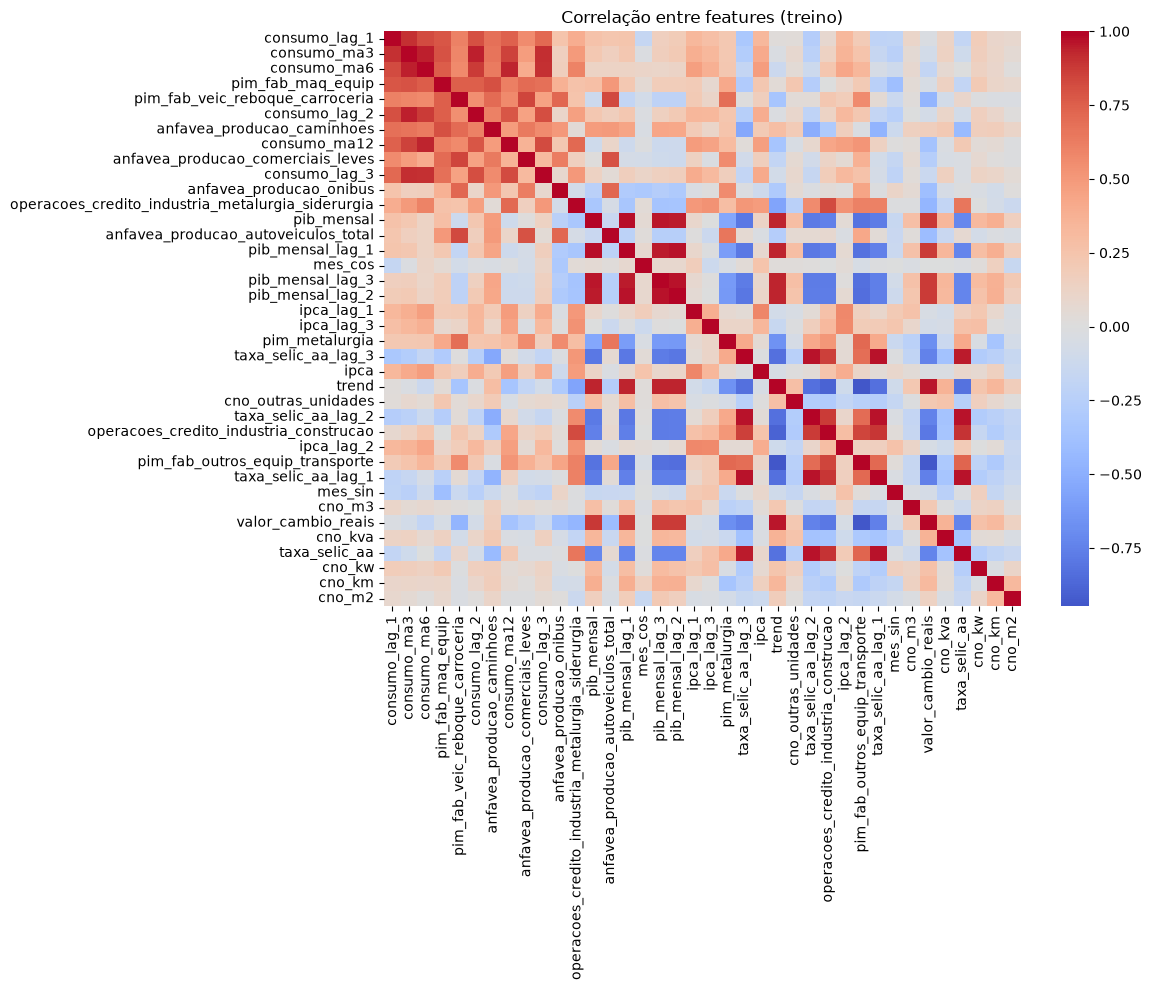

In [61]:
plt.figure(figsize=(12, 10))
sns.heatmap(X_train.corr(), annot=False, cmap='coolwarm', center=0)
plt.title('Correlação entre features (treino)')
plt.tight_layout()
plt.savefig(f'./{path_secao_atual}/correlation_train.png', bbox_inches='tight')

## Seleção de Features — Etapa 2: Permutation Importance no Val Set

Treina um XGBoost base no conjunto de treino e mede, para cada feature, o quanto o MAPE no val (2024) piora quando ela é permutada aleatoriamente. Features com importância ≤ 0 não contribuem fora do treino e são descartadas.

In [62]:
"""
# Modelo base conservador — serve apenas para guiar a seleção, não é o modelo final
_sel_model = XGBRegressor(
    n_estimators=200, max_depth=3, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.5, reg_lambda=1.0, random_state=0,
)
_sel_model.fit(X_train, y_train, sample_weight=pesos_train)

# n_repeats=50: cada feature é permutada 50 vezes → média e desvio estáveis mesmo com val pequeno (12 obs)
result_perm = perm_imp(
    _sel_model, X_val, y_val,
    n_repeats=50,
    scoring='neg_mean_absolute_percentage_error',
    random_state=0,
    n_jobs=-1,
)

perm_df = pd.DataFrame({
    'Feature':         list(X_train.columns),
    'Importance_mean': result_perm.importances_mean,
    'Importance_std':  result_perm.importances_std,
}).sort_values('Importance_mean', ascending=False).reset_index(drop=True)

print("Permutation Importance no Val (positivo = permutação piora o MAPE = feature é útil):")
print(perm_df.to_string(index=False))

# Visualização com barras de erro
fig, ax = plt.subplots(figsize=(9, max(4, len(perm_df) * 0.50)))
colors_pi = ['steelblue' if v > 0 else 'lightcoral' for v in perm_df['Importance_mean'][::-1]]
ax.barh(
    perm_df['Feature'][::-1],
    perm_df['Importance_mean'][::-1],
    xerr=perm_df['Importance_std'][::-1],
    color=colors_pi, alpha=0.85,
)
ax.axvline(0, color='red', linestyle='--', alpha=0.8, label='Limiar = 0')
ax.set_xlabel('Importância por Permutação (neg MAPE — maior = mais importante)')
ax.set_title('Etapa 2 — Permutation Importance no Val Set (2024)')
ax.legend()
plt.tight_layout()
plt.savefig(f'./{path_secao_atual}/etapa2_permutation_importance.png', bbox_inches='tight')
"""

'\n# Modelo base conservador — serve apenas para guiar a seleção, não é o modelo final\n_sel_model = XGBRegressor(\n    n_estimators=200, max_depth=3, learning_rate=0.05,\n    subsample=0.8, colsample_bytree=0.8,\n    reg_alpha=0.5, reg_lambda=1.0, random_state=0,\n)\n_sel_model.fit(X_train, y_train, sample_weight=pesos_train)\n\n# n_repeats=50: cada feature é permutada 50 vezes → média e desvio estáveis mesmo com val pequeno (12 obs)\nresult_perm = perm_imp(\n    _sel_model, X_val, y_val,\n    n_repeats=50,\n    scoring=\'neg_mean_absolute_percentage_error\',\n    random_state=0,\n    n_jobs=-1,\n)\n\nperm_df = pd.DataFrame({\n    \'Feature\':         list(X_train.columns),\n    \'Importance_mean\': result_perm.importances_mean,\n    \'Importance_std\':  result_perm.importances_std,\n}).sort_values(\'Importance_mean\', ascending=False).reset_index(drop=True)\n\nprint("Permutation Importance no Val (positivo = permutação piora o MAPE = feature é útil):")\nprint(perm_df.to_string(index=

In [63]:
"""
# Manter features onde a permutação degrada o MAPE (importance_mean > 0)
SELECTED_FEATURES_PERM = perm_df[perm_df['Importance_mean'] > 0]['Feature'].tolist()

# Garantir que os lags do target de curto prazo sempre entrem
# (podem ser descartados por correlação mútua entre si)
FORCE_INCLUDE = [f for f in ['consumo_lag_1', 'consumo_lag_2', 'consumo_ma3']
                 if f in X_train.columns and f not in SELECTED_FEATURES_PERM]
SELECTED_FEATURES_PERM = FORCE_INCLUDE + SELECTED_FEATURES_PERM

removed_perm = [f for f in X_train.columns if f not in SELECTED_FEATURES_PERM]
print(f"Etapa 2 — removidas ({len(removed_perm)}): {removed_perm or 'nenhuma'}")
print(f"Etapa 2 — mantidas  ({len(SELECTED_FEATURES_PERM)}): {SELECTED_FEATURES_PERM}")

# Atualizar todas as matrizes X com o set final de features
X_train    = X_train[SELECTED_FEATURES_PERM]
X_val      = X_val[SELECTED_FEATURES_PERM]
X_test     = X_test[SELECTED_FEATURES_PERM]
X_trainval = X_trainval[SELECTED_FEATURES_PERM]

print(f"\nShapes finais: X_train={X_train.shape}  X_val={X_val.shape}  X_test={X_test.shape}")
"""

'\n# Manter features onde a permutação degrada o MAPE (importance_mean > 0)\nSELECTED_FEATURES_PERM = perm_df[perm_df[\'Importance_mean\'] > 0][\'Feature\'].tolist()\n\n# Garantir que os lags do target de curto prazo sempre entrem\n# (podem ser descartados por correlação mútua entre si)\nFORCE_INCLUDE = [f for f in [\'consumo_lag_1\', \'consumo_lag_2\', \'consumo_ma3\']\n                 if f in X_train.columns and f not in SELECTED_FEATURES_PERM]\nSELECTED_FEATURES_PERM = FORCE_INCLUDE + SELECTED_FEATURES_PERM\n\nremoved_perm = [f for f in X_train.columns if f not in SELECTED_FEATURES_PERM]\nprint(f"Etapa 2 — removidas ({len(removed_perm)}): {removed_perm or \'nenhuma\'}")\nprint(f"Etapa 2 — mantidas  ({len(SELECTED_FEATURES_PERM)}): {SELECTED_FEATURES_PERM}")\n\n# Atualizar todas as matrizes X com o set final de features\nX_train    = X_train[SELECTED_FEATURES_PERM]\nX_val      = X_val[SELECTED_FEATURES_PERM]\nX_test     = X_test[SELECTED_FEATURES_PERM]\nX_trainval = X_trainval[SELEC

# Ajustar o modelo

## Baseline: SARIMA

Grid search por AIC sobre um espaço compacto de ordens. O SARIMA usa apenas a série temporal do target, sem features externas. Serve como referência mínima: se o XGBoost não bater o SARIMA, há problema na modelagem.

In [64]:
train_ts    = df_train.set_index('data')[target_col].sort_index()
trainval_ts = df_trainval.set_index('data')[target_col].sort_index()
val_ts      = df_val.set_index('data')[target_col].sort_index()
test_ts     = df_test.set_index('data')[target_col].sort_index()

# Espaço de busca definido em SARIMA_P/D/Q e SARIMA_SAZONAL_P/D/Q
_p, _d, _q = SARIMA_P, SARIMA_D, SARIMA_Q
_P, _D, _Q = SARIMA_SAZONAL_P, SARIMA_SAZONAL_D, SARIMA_SAZONAL_Q
_s = SARIMA_S

best_aic   = np.inf
sarima_order         = None
sarima_seasonal_order = None

print("Grid search SARIMA — seleção por AIC no conjunto de treino...")
for p, d, q, P, D, Q in itertools.product(_p, _d, _q, _P, _D, _Q):
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            res = SARIMAX(
                train_ts,
                order=(p, d, q),
                seasonal_order=(P, D, Q, _s),
                enforce_stationarity=False,
                enforce_invertibility=False,
            ).fit(disp=False)
        if res.aic < best_aic:
            best_aic             = res.aic
            sarima_order         = (p, d, q)
            sarima_seasonal_order = (P, D, Q, _s)
    except Exception:
        continue

print(f"Melhor ordem:          SARIMA{sarima_order}×{sarima_seasonal_order}")
print(f"AIC (treino):          {best_aic:.2f}")

Grid search SARIMA — seleção por AIC no conjunto de treino...
Melhor ordem:          SARIMA(1, 1, 2)×(0, 1, 1, 12)
AIC (treino):          763.91


In [65]:
# --- Ajuste em treino → previsão para val (espelha o protocolo do XGBoost) ---
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    sarima_fit_train = SARIMAX(
        train_ts,
        order=sarima_order,
        seasonal_order=sarima_seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False,
    ).fit(disp=False)

sarima_val_pred = sarima_fit_train.forecast(steps=len(val_ts))
sarima_val_pred.index = val_ts.index

# --- Ajuste em trainval → previsão para test (modelo final, igual ao XGBoost) ---
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    sarima_fit_trainval = SARIMAX(
        trainval_ts,
        order=sarima_order,
        seasonal_order=sarima_seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False,
    ).fit(disp=False)

sarima_test_pred = sarima_fit_trainval.forecast(steps=len(test_ts))
sarima_test_pred.index = test_ts.index

# --- Métricas SARIMA ---
sarima_r2_val    = np.round(r2_score(val_ts,  sarima_val_pred),  4)
sarima_mae_val   = np.round(mean_absolute_error(val_ts,  sarima_val_pred), 4)
sarima_mape_val  = np.round(mean_absolute_percentage_error(val_ts,  sarima_val_pred), 4)

sarima_r2_test   = np.round(r2_score(test_ts, sarima_test_pred), 4)
sarima_mae_test  = np.round(mean_absolute_error(test_ts, sarima_test_pred), 4)
sarima_mape_test = np.round(mean_absolute_percentage_error(test_ts, sarima_test_pred), 4)

print(f"SARIMA{sarima_order}×{sarima_seasonal_order} — resultados:")
print(f"{'Conjunto':<14} {'R²':>6}  {'MAE':>8}  {'MAPE':>7}")
print(f"{'Val  (2024)':<14} {sarima_r2_val:>6.4f}  {sarima_mae_val:>8.3f}  {sarima_mape_val:>7.4f}")
print(f"{'Teste (2025)':<14} {sarima_r2_test:>6.4f}  {sarima_mae_test:>8.3f}  {sarima_mape_test:>7.4f}")

SARIMA(1, 1, 2)×(0, 1, 1, 12) — resultados:
Conjunto           R²       MAE     MAPE
Val  (2024)    0.3000    56.871   0.0718
Teste (2025)   0.5226    43.900   0.0536


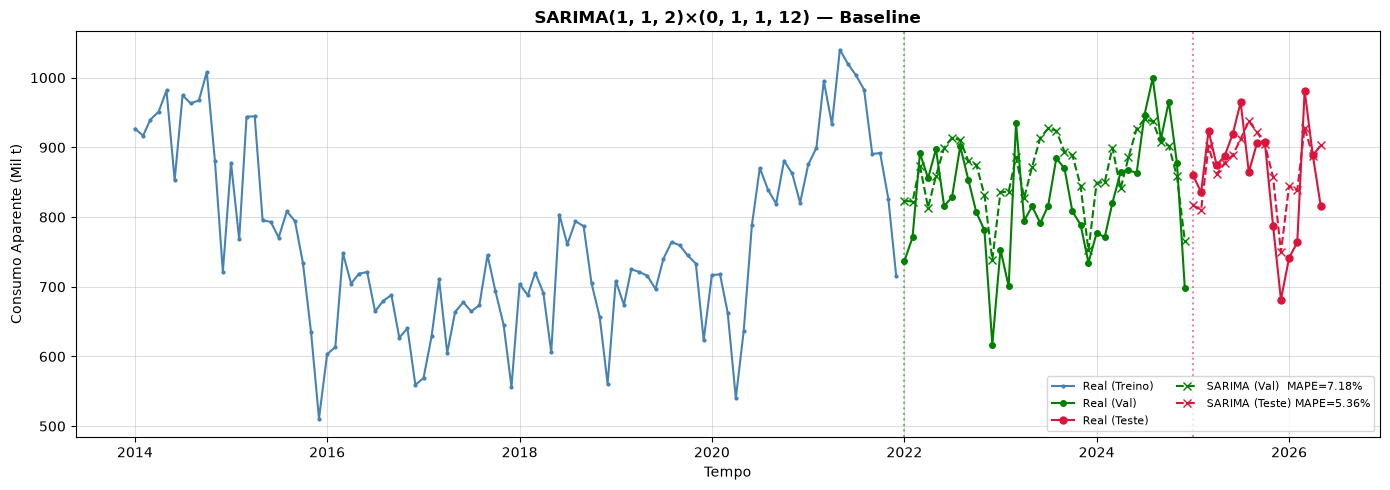

In [66]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(train_ts.index, train_ts.values, label='Real (Treino)', color='steelblue', marker='o', markersize=2)
ax.plot(val_ts.index,   val_ts.values,   label='Real (Val)',    color='green',     marker='o', markersize=4)
ax.plot(test_ts.index,  test_ts.values,  label='Real (Teste)',  color='crimson',   marker='o', markersize=5)

ax.plot(sarima_val_pred.index,  sarima_val_pred.values,  label=f'SARIMA (Val)  MAPE={sarima_mape_val:.2%}',  color='green',   linestyle='--', marker='x', markersize=6)
ax.plot(sarima_test_pred.index, sarima_test_pred.values, label=f'SARIMA (Teste) MAPE={sarima_mape_test:.2%}', color='crimson', linestyle='--', marker='x', markersize=6)

ax.axvline(pd.Timestamp(DATA_INICIO_VAL), color='green',  linestyle=':', alpha=0.5)
ax.axvline(pd.Timestamp(DATA_INICIO_TESTE), color='crimson', linestyle=':', alpha=0.5)

ax.set_title(f'SARIMA{sarima_order}×{sarima_seasonal_order} — Baseline', fontsize=12, fontweight='bold')
ax.set_xlabel('Tempo')
ax.set_ylabel('Consumo Aparente (Mil t)')
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig(f'./{path_secao_atual}/sarima_baseline_r2_val_{sarima_r2_val}_r2_test_{sarima_r2_test}.png', bbox_inches='tight')

## SARIMAX — SARIMA com Regressores Externos

Mantém a estrutura temporal do SARIMA (diferenciação sazonal, MA) e adiciona as
features externas validadas como regressores exógenos. Combina a capacidade do
SARIMA de capturar variância temporal com o poder explicativo das variáveis macro/industriais.

In [67]:
# Features externas = colunas selecionadas pelo pipeline que NÃO são lags/rolling do target
# Usa X_train.columns para aproveitar a seleção já validada (correlação + permutation importance)
EXT_FEATURES_SARIMAX = [
    col for col in X_train.columns
    if not col.startswith('consumo_')
    and col not in ('mes_sin', 'mes_cos', 'trend')
]

print(f'Regressores exógenos ({len(EXT_FEATURES_SARIMAX)}):', EXT_FEATURES_SARIMAX)

if not EXT_FEATURES_SARIMAX:
    print('Nenhum regressor externo — SARIMAX == SARIMA. Abortando.')
else:
    exog_train    = df_train[EXT_FEATURES_SARIMAX].values
    exog_val      = df_val[EXT_FEATURES_SARIMAX].values
    exog_trainval = df_trainval[EXT_FEATURES_SARIMAX].values
    exog_test     = df_test[EXT_FEATURES_SARIMAX].values

    # ── Treino → Val ──────────────────────────────────────────────────────────
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        sarimax_fit_train = SARIMAX(
            train_ts,
            exog=exog_train,
            order=sarima_order,
            seasonal_order=sarima_seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False,
        ).fit(disp=False)

    sarimax_val_pred = sarimax_fit_train.forecast(steps=len(val_ts), exog=exog_val)
    sarimax_val_pred.index = val_ts.index

    # ── Trainval → Teste (modelo final) ───────────────────────────────────────
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        sarimax_fit_trainval = SARIMAX(
            trainval_ts,
            exog=exog_trainval,
            order=sarima_order,
            seasonal_order=sarima_seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False,
        ).fit(disp=False)

    sarimax_test_pred = sarimax_fit_trainval.forecast(steps=len(test_ts), exog=exog_test)
    sarimax_test_pred.index = test_ts.index

    # ── Métricas ──────────────────────────────────────────────────────────────
    sarimax_r2_val   = np.round(r2_score(val_ts,  sarimax_val_pred),  4)
    sarimax_mae_val  = np.round(mean_absolute_error(val_ts,  sarimax_val_pred), 4)
    sarimax_mape_val = np.round(mean_absolute_percentage_error(val_ts,  sarimax_val_pred), 4)

    sarimax_r2_test   = np.round(r2_score(test_ts, sarimax_test_pred), 4)
    sarimax_mae_test  = np.round(mean_absolute_error(test_ts, sarimax_test_pred), 4)
    sarimax_mape_test = np.round(mean_absolute_percentage_error(test_ts, sarimax_test_pred), 4)

    print(f'\nSARIMAX{sarima_order}×{sarima_seasonal_order} + {EXT_FEATURES_SARIMAX}')
    print(f'{"Conjunto":<14} {"R²":>6}  {"MAE":>8}  {"MAPE":>7}')
    print(f'{"Val  (2024)":<14} {sarimax_r2_val:>6.4f}  {sarimax_mae_val:>8.3f}  {sarimax_mape_val:>7.4f}')
    print(f'{"Teste (2025)":<14} {sarimax_r2_test:>6.4f}  {sarimax_mae_test:>8.3f}  {sarimax_mape_test:>7.4f}')
    print(f'\nResidual std (val):  {sarimax_fit_train.resid.std():.2f} Mil t')
    print(f'Residual std (trainval): {sarimax_fit_trainval.resid.std():.2f} Mil t')


Regressores exógenos (29): ['pim_fab_maq_equip', 'pim_fab_veic_reboque_carroceria', 'anfavea_producao_caminhoes', 'anfavea_producao_comerciais_leves', 'anfavea_producao_onibus', 'operacoes_credito_industria_metalurgia_siderurgia', 'pib_mensal', 'anfavea_producao_autoveiculos_total', 'pib_mensal_lag_1', 'pib_mensal_lag_3', 'pib_mensal_lag_2', 'ipca_lag_1', 'ipca_lag_3', 'pim_metalurgia', 'taxa_selic_aa_lag_3', 'ipca', 'cno_outras_unidades', 'taxa_selic_aa_lag_2', 'operacoes_credito_industria_construcao', 'ipca_lag_2', 'pim_fab_outros_equip_transporte', 'taxa_selic_aa_lag_1', 'cno_m3', 'valor_cambio_reais', 'cno_kva', 'taxa_selic_aa', 'cno_kw', 'cno_km', 'cno_m2']

SARIMAX(1, 1, 2)×(0, 1, 1, 12) + ['pim_fab_maq_equip', 'pim_fab_veic_reboque_carroceria', 'anfavea_producao_caminhoes', 'anfavea_producao_comerciais_leves', 'anfavea_producao_onibus', 'operacoes_credito_industria_metalurgia_siderurgia', 'pib_mensal', 'anfavea_producao_autoveiculos_total', 'pib_mensal_lag_1', 'pib_mensal_lag_3'

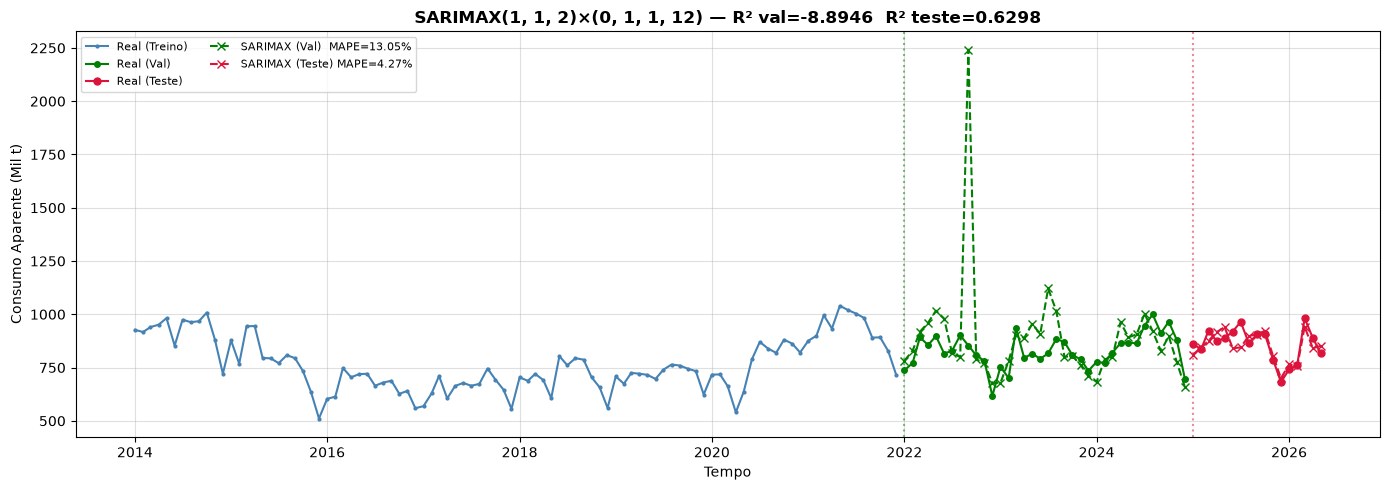

In [68]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(train_ts.index, train_ts.values,
        label='Real (Treino)', color='steelblue', marker='o', markersize=2)
ax.plot(val_ts.index,   val_ts.values,
        label='Real (Val)',   color='green',     marker='o', markersize=4)
ax.plot(test_ts.index,  test_ts.values,
        label='Real (Teste)', color='crimson',  marker='o', markersize=5)

ax.plot(sarimax_val_pred.index,  sarimax_val_pred.values,
        label=f'SARIMAX (Val)  MAPE={sarimax_mape_val:.2%}',
        color='green',   linestyle='--', marker='x', markersize=6)
ax.plot(sarimax_test_pred.index, sarimax_test_pred.values,
        label=f'SARIMAX (Teste) MAPE={sarimax_mape_test:.2%}',
        color='crimson', linestyle='--', marker='x', markersize=6)

ax.axvline(pd.Timestamp(DATA_INICIO_VAL), color='green',  linestyle=':', alpha=0.5)
ax.axvline(pd.Timestamp(DATA_INICIO_TESTE), color='crimson', linestyle=':', alpha=0.5)

ax.set_title(
    f'SARIMAX{sarima_order}×{sarima_seasonal_order} — '
    f'R² val={sarimax_r2_val}  R² teste={sarimax_r2_test}',
    fontsize=12, fontweight='bold')
ax.set_xlabel('Tempo')
ax.set_ylabel('Consumo Aparente (Mil t)')
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig(
    f'./{path_secao_atual}/sarimax_r2_val_{sarimax_r2_val}_r2_test_{sarimax_r2_test}.png',
    bbox_inches='tight')


In [69]:
def objective(trial):
    param = {
        'n_estimators':       trial.suggest_int('n_estimators', 50, 600),
        'max_depth':          trial.suggest_int('max_depth', 2, 5),
        'learning_rate':      trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'subsample':          trial.suggest_float('subsample', 0.5, 0.9),
        'colsample_bytree':   trial.suggest_float('colsample_bytree', 0.5, 0.9),
        'min_child_weight':   trial.suggest_int('min_child_weight', 3, 15),
        'gamma':              trial.suggest_float('gamma', 1e-4, 5.0, log=True),
        'reg_alpha':          trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda':         trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'random_state':       0,
        'early_stopping_rounds': OPTUNA_EARLY_STOPPING_ROUNDS,
    }
    model_opt = XGBRegressor(**param)
    # eval_set usa VAL (não test!) — early stopping sem leakage do conjunto de teste
    model_opt.fit(
        X_train, y_train,
        sample_weight=pesos_train,
        eval_set=[(X_val, y_val)],
        verbose=False,
    )
    y_pred_val = model_opt.predict(X_val)
    return mean_squared_error(y_val, y_pred_val)

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=OPTUNA_N_TRIALS)

print('Melhores parâmetros (Optuna):')
print(study.best_params)
print(f'Menor MSE (val): {study.best_value:.2f}')

# Walk-forward CV — avaliação mais robusta usando todo o histórico trainval
tscv_wf = TimeSeriesSplit(n_splits=WALK_FORWARD_N_SPLITS, test_size=WALK_FORWARD_TEST_SIZE)
cv_mapes = []
for fold, (tr_idx, vl_idx) in enumerate(tscv_wf.split(X_trainval)):
    X_cv_tr, X_cv_vl = X_trainval.iloc[tr_idx], X_trainval.iloc[vl_idx]
    y_cv_tr, y_cv_vl = y_trainval.iloc[tr_idx], y_trainval.iloc[vl_idx]
    w_cv_tr = pesos_trainval[tr_idx]
    m = XGBRegressor(**{k: v for k, v in study.best_params.items()}, random_state=0)
    m.fit(X_cv_tr, y_cv_tr, sample_weight=w_cv_tr)
    fold_mape = mean_absolute_percentage_error(y_cv_vl, m.predict(X_cv_vl))
    cv_mapes.append(fold_mape)
    print(f"  Fold {fold+1}: MAPE = {fold_mape:.4f}")

print(f"\nWalk-forward CV MAPE: {np.mean(cv_mapes):.4f} ± {np.std(cv_mapes):.4f}")

# Modelo final: treinado em trainval completo, avaliado no test (2025)
best_params_clean = {k: v for k, v in study.best_params.items()}
best_model = XGBRegressor(**best_params_clean, random_state=0)
best_model.fit(X_trainval, y_trainval, sample_weight=pesos_trainval)

y_pred_train_opt = best_model.predict(X_train)
y_pred_val_opt   = best_model.predict(X_val)
y_pred_test_opt  = best_model.predict(X_test)

mse_train_opt  = np.round(mean_squared_error(y_train, y_pred_train_opt), 4)
r2_train_opt   = np.round(r2_score(y_train, y_pred_train_opt), 4)
mae_train_opt  = np.round(mean_absolute_error(y_train, y_pred_train_opt), 4)
mape_train_opt = np.round(mean_absolute_percentage_error(y_train, y_pred_train_opt), 4)

mse_val_opt    = np.round(mean_squared_error(y_val, y_pred_val_opt), 4)
r2_val_opt     = np.round(r2_score(y_val, y_pred_val_opt), 4)
mae_val_opt    = np.round(mean_absolute_error(y_val, y_pred_val_opt), 4)
mape_val_opt   = np.round(mean_absolute_percentage_error(y_val, y_pred_val_opt), 4)

mse_test_opt   = np.round(mean_squared_error(y_test, y_pred_test_opt), 4)
r2_test_opt    = np.round(r2_score(y_test, y_pred_test_opt), 4)
mae_test_opt   = np.round(mean_absolute_error(y_test, y_pred_test_opt), 4)
mape_test_opt  = np.round(mean_absolute_percentage_error(y_test, y_pred_test_opt), 4)

[I 2026-07-01 17:10:09,059] A new study created in memory with name: no-name-a5716bdf-9c73-48de-ad77-953bc951e8cb
[I 2026-07-01 17:10:09,115] Trial 0 finished with value: 5477.260883158535 and parameters: {'n_estimators': 394, 'max_depth': 5, 'learning_rate': 0.020820136665717533, 'subsample': 0.5084925039391556, 'colsample_bytree': 0.6971391504861417, 'min_child_weight': 4, 'gamma': 0.0013189374806139335, 'reg_alpha': 0.6241025503111748, 'reg_lambda': 0.10343373746698702}. Best is trial 0 with value: 5477.260883158535.
[I 2026-07-01 17:10:09,164] Trial 1 finished with value: 5603.02938814168 and parameters: {'n_estimators': 523, 'max_depth': 5, 'learning_rate': 0.02249951653378679, 'subsample': 0.8357135564675697, 'colsample_bytree': 0.5397998763352437, 'min_child_weight': 6, 'gamma': 0.9480975419631822, 'reg_alpha': 0.025662052944440072, 'reg_lambda': 0.012947790654563314}. Best is trial 0 with value: 5477.260883158535.
[I 2026-07-01 17:10:09,183] Trial 2 finished with value: 6309.52

Melhores parâmetros (Optuna):
{'n_estimators': 231, 'max_depth': 3, 'learning_rate': 0.09311538123801986, 'subsample': 0.5589293382940239, 'colsample_bytree': 0.5045760117038088, 'min_child_weight': 4, 'gamma': 0.0055962560245517235, 'reg_alpha': 0.003529560879788965, 'reg_lambda': 0.1511695426044663}
Menor MSE (val): 3854.52
  Fold 1: MAPE = 0.2273
  Fold 2: MAPE = 0.1242
  Fold 3: MAPE = 0.0651
  Fold 4: MAPE = 0.0894
  Fold 5: MAPE = 0.0727
  Fold 6: MAPE = 0.0486
  Fold 7: MAPE = 0.0458
  Fold 8: MAPE = 0.0753

Walk-forward CV MAPE: 0.0936 ± 0.0556


In [70]:
print('-' * 55)
print('--- Resultados — XGBoost + Optuna ---')
print(f'{"Conjunto":<12} {"R²":>6}  {"MSE":>10}  {"MAE":>8}  {"MAPE":>7}')
print(f'{"Treino":<12} {r2_train_opt:>6.4f}  {mse_train_opt:>10.2f}  {mae_train_opt:>8.3f}  {mape_train_opt:>7.4f}')
print(f'{"Val (2024)":<12} {r2_val_opt:>6.4f}  {mse_val_opt:>10.2f}  {mae_val_opt:>8.3f}  {mape_val_opt:>7.4f}')
print(f'{"Teste (2025)":<12} {r2_test_opt:>6.4f}  {mse_test_opt:>10.2f}  {mae_test_opt:>8.3f}  {mape_test_opt:>7.4f}')
print(f'\nWalk-forward CV MAPE: {np.mean(cv_mapes):.4f} ± {np.std(cv_mapes):.4f}')

-------------------------------------------------------
--- Resultados — XGBoost + Optuna ---
Conjunto         R²         MSE       MAE     MAPE
Treino       0.6745     5231.06    56.529   0.0810
Val (2024)   0.9024      609.93    17.622   0.0222
Teste (2025) 0.3204     4090.04    48.605   0.0559

Walk-forward CV MAPE: 0.0936 ± 0.0556


### Comparação Final: SARIMA vs SARIMAX vs XGBoost

In [71]:
comparison3 = pd.DataFrame({
    'Modelo':   [
        f'SARIMA{sarima_order}×{sarima_seasonal_order}',
        f'SARIMA{sarima_order}×{sarima_seasonal_order}',
        f'SARIMAX{sarima_order}×{sarima_seasonal_order}',
        f'SARIMAX{sarima_order}×{sarima_seasonal_order}',
        'XGBoost', 'XGBoost',
    ],
    'Conjunto': ['Val (2024)', 'Teste (2025)'] * 3,
    'R²':       [sarima_r2_val,   sarima_r2_test,
                 sarimax_r2_val,  sarimax_r2_test,
                 r2_val_opt,      r2_test_opt],
    'MAE':      [sarima_mae_val,  sarima_mae_test,
                 sarimax_mae_val, sarimax_mae_test,
                 mae_val_opt,     mae_test_opt],
    'MAPE':     [sarima_mape_val,  sarima_mape_test,
                 sarimax_mape_val, sarimax_mape_test,
                 mape_val_opt,     mape_test_opt],
})
print(comparison3.to_string(index=False))

# Melhor modelo no teste por MAPE
test_rows = comparison3[comparison3['Conjunto'] == 'Teste (2025)']
best_mape_model = test_rows.loc[test_rows['MAPE'].idxmin(), 'Modelo']
best_r2_model   = test_rows.loc[test_rows['R²'].idxmax(),   'Modelo']
print(f'\nMelhor MAPE no teste: {best_mape_model}')
print(f'Melhor R²   no teste: {best_r2_model}')


                        Modelo     Conjunto      R²      MAE   MAPE
 SARIMA(1, 1, 2)×(0, 1, 1, 12)   Val (2024)  0.3000  56.8706 0.0718
 SARIMA(1, 1, 2)×(0, 1, 1, 12) Teste (2025)  0.5226  43.8997 0.0536
SARIMAX(1, 1, 2)×(0, 1, 1, 12)   Val (2024) -8.8946 109.1909 0.1305
SARIMAX(1, 1, 2)×(0, 1, 1, 12) Teste (2025)  0.6298  37.7443 0.0427
                       XGBoost   Val (2024)  0.9024  17.6219 0.0222
                       XGBoost Teste (2025)  0.3204  48.6045 0.0559

Melhor MAPE no teste: SARIMAX(1, 1, 2)×(0, 1, 1, 12)
Melhor R²   no teste: SARIMAX(1, 1, 2)×(0, 1, 1, 12)


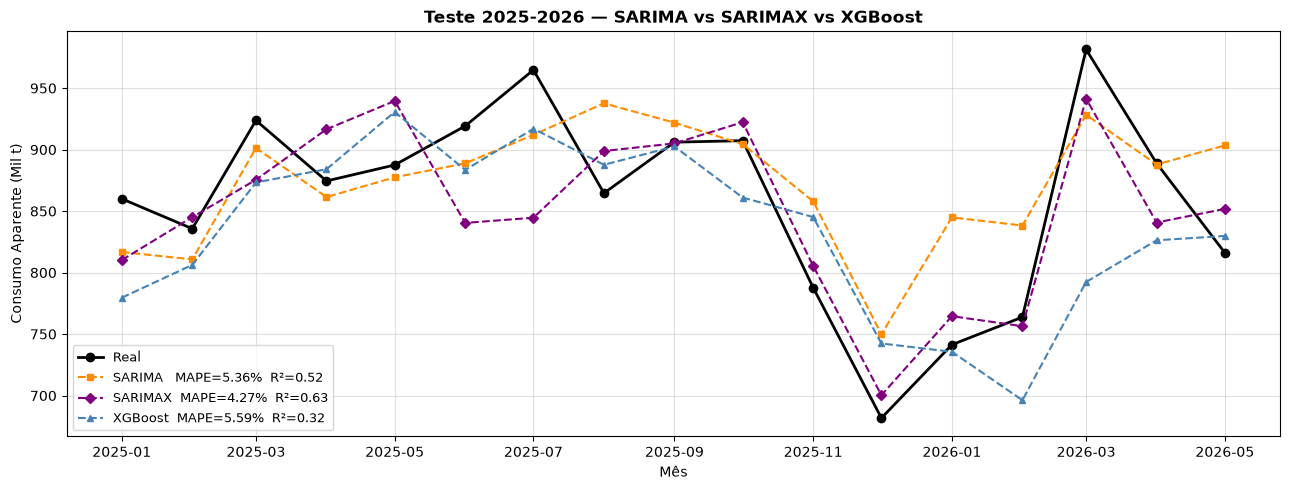

In [72]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(test_ts.index, test_ts.values,
        label='Real', color='black', marker='o', markersize=6, linewidth=2)

ax.plot(test_ts.index, sarima_test_pred.values,
        label=f'SARIMA   MAPE={sarima_mape_test:.2%}  R²={sarima_r2_test:.2f}',
        color='darkorange', linestyle='--', marker='s', markersize=5)

ax.plot(test_ts.index, sarimax_test_pred.values,
        label=f'SARIMAX  MAPE={sarimax_mape_test:.2%}  R²={sarimax_r2_test:.2f}',
        color='purple', linestyle='--', marker='D', markersize=5)

ax.plot(test_ts.index, y_pred_test_opt,
        label=f'XGBoost  MAPE={mape_test_opt:.2%}  R²={r2_test_opt:.2f}',
        color='steelblue', linestyle='--', marker='^', markersize=5)

ax.set_title('Teste 2025-2026 — SARIMA vs SARIMAX vs XGBoost',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Mês')
ax.set_ylabel('Consumo Aparente (Mil t)')
ax.legend(fontsize=9)
ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig(f'./{path_secao_atual}/comparacao_3modelos_teste.png', bbox_inches='tight')


## Previsão com Horizonte Real (Recursive Multi-Step Forecasting)

O modelo avaliado até aqui usa lags e features externas *já conhecidos* no momento da previsão — isso é **nowcasting**, não forecasting.

Para gerar um horizonte real de N meses à frente:

1. **Retreinar em todo o histórico disponível** (incluindo o período de teste).
2. **Lags do target**: atualizados recursivamente com as previsões anteriores.
3. **Features externas** (PIM, ANFAVEA, etc.): mantidas no último valor observado — proxy conservador que evita vazar informação futura desconhecida.

A incerteza cresce com o horizonte porque erros de previsão se propagam nos lags.

In [73]:
# Identificar os tipos de cada feature dinamicamente
_lag_map  = {}   # col -> lag int
_roll_map = {}   # col -> janela int
_ext_cols = []   # features externas (sem defasagem natural)

for col in X_train.columns:
    if col.startswith('consumo_lag_'):
        _lag_map[col] = int(col.split('_')[-1])
    elif col.startswith('consumo_ma'):
        _roll_map[col] = int(col.replace('consumo_ma', ''))
    elif col not in ('mes_sin', 'mes_cos', 'trend'):
        _ext_cols.append(col)

print(f'Lags recursivos:  {_lag_map}')
print(f'Rolling recursivos: {_roll_map}')
print(f'Features externas (fixas): {_ext_cols}')

# ── Retreinar em todo o histórico (inclui test 2025) ──────────────────────────
X_all = df_tabela_mestre[list(X_train.columns)].copy()
y_all = df_tabela_mestre[target_col].copy()
n_all = len(y_all)
pesos_all = lambda_fator ** np.arange(n_all - 1, -1, -1)

best_params_deploy = {k: v for k, v in study.best_params.items()
                      if k != 'early_stopping_rounds'}
model_full = XGBRegressor(**best_params_deploy, random_state=0)
model_full.fit(X_all, y_all, sample_weight=pesos_all)
print(f'\nRetreino: {n_all} obs  '
      f'({df_tabela_mestre["data"].min().date()} → {df_tabela_mestre["data"].max().date()})')

# ── Previsão recursiva ────────────────────────────────────────────────────────
serie_hist   = list(df_tabela_mestre[target_col].values)  # buffer crescente
ultima_data  = df_tabela_mestre['data'].max()
ultima_linha = df_tabela_mestre.iloc[-1]                  # valores fixos externos
trend_base   = int(df_tabela_mestre['trend'].max()) if 'trend' in df_tabela_mestre.columns else 0

previsoes_fut = []
datas_fut     = []

for h in range(1, N_HORIZONS + 1):
    prox_data = ultima_data + pd.DateOffset(months=h)
    X_next = {}

    for col in X_train.columns:
        if col in _lag_map:
            # lag atualizado recursivamente com previsões anteriores
            X_next[col] = serie_hist[-_lag_map[col]]
        elif col in _roll_map:
            w = _roll_map[col]
            X_next[col] = float(np.mean(serie_hist[-w:]))
        elif col == 'mes_sin':
            X_next[col] = np.sin(2 * np.pi * prox_data.month / 12)
        elif col == 'mes_cos':
            X_next[col] = np.cos(2 * np.pi * prox_data.month / 12)
        elif col == 'trend':
            X_next[col] = trend_base + h
        else:
            # feature externa: último valor conhecido (assumir sem mudança)
            X_next[col] = float(ultima_linha[col])

    pred = float(model_full.predict(pd.DataFrame([X_next])[list(X_train.columns)])[0])
    serie_hist.append(pred)   # alimenta os lags da próxima etapa
    previsoes_fut.append(pred)
    datas_fut.append(prox_data)

forecast_df = pd.DataFrame({'Data': datas_fut, 'Previsao': previsoes_fut})
print(f'\nPrevisão recursiva — {N_HORIZONS} meses à frente:')
print(forecast_df.assign(Data=forecast_df['Data'].dt.strftime('%Y-%m')).to_string(index=False))


Lags recursivos:  {'consumo_lag_1': 1, 'consumo_lag_2': 2, 'consumo_lag_3': 3}
Rolling recursivos: {'consumo_ma3': 3, 'consumo_ma6': 6, 'consumo_ma12': 12}
Features externas (fixas): ['pim_fab_maq_equip', 'pim_fab_veic_reboque_carroceria', 'anfavea_producao_caminhoes', 'anfavea_producao_comerciais_leves', 'anfavea_producao_onibus', 'operacoes_credito_industria_metalurgia_siderurgia', 'pib_mensal', 'anfavea_producao_autoveiculos_total', 'pib_mensal_lag_1', 'pib_mensal_lag_3', 'pib_mensal_lag_2', 'ipca_lag_1', 'ipca_lag_3', 'pim_metalurgia', 'taxa_selic_aa_lag_3', 'ipca', 'cno_outras_unidades', 'taxa_selic_aa_lag_2', 'operacoes_credito_industria_construcao', 'ipca_lag_2', 'pim_fab_outros_equip_transporte', 'taxa_selic_aa_lag_1', 'cno_m3', 'valor_cambio_reais', 'cno_kva', 'taxa_selic_aa', 'cno_kw', 'cno_km', 'cno_m2']

Retreino: 149 obs  (2014-01-01 → 2026-05-01)

Previsão recursiva — 12 meses à frente:
   Data   Previsao
2026-06 809.812805
2026-07 804.954590
2026-08 793.332825
2026-09 78

Gráfico salvo.


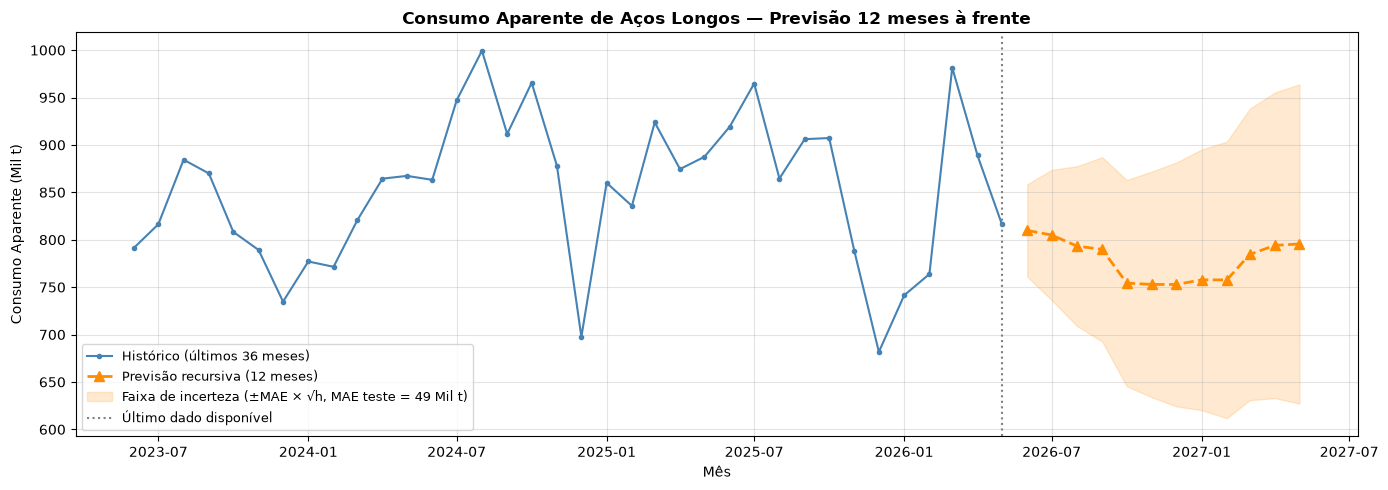

In [74]:
# Contexto histórico (últimos JANELA_PLOT_HISTORICO meses) + previsão futura
hist_plot = df_tabela_mestre.set_index('data')[target_col].sort_index()
hist_ctx  = hist_plot.iloc[-JANELA_PLOT_HISTORICO:]

# Banda de incerteza: ±MAE do test como proxy de erro de 1 passo;
# aumenta proporcionalmente com o horizonte (erro acumula recursivamente)
mae_ref     = mae_test_opt
horizons    = np.arange(1, N_HORIZONS + 1)
error_bands = mae_ref * np.sqrt(horizons)  # ≈ erro de uma random walk

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(hist_ctx.index, hist_ctx.values,
        label='Histórico (últimos 36 meses)', color='steelblue',
        marker='o', markersize=3)

ax.plot(forecast_df['Data'], forecast_df['Previsao'],
        label=f'Previsão recursiva ({N_HORIZONS} meses)', color='darkorange',
        linestyle='--', marker='^', markersize=7, linewidth=2)

ax.fill_between(
    forecast_df['Data'],
    forecast_df['Previsao'] - error_bands,
    forecast_df['Previsao'] + error_bands,
    alpha=0.18, color='darkorange',
    label=f'Faixa de incerteza (±MAE × √h, MAE teste = {mae_ref:.0f} Mil t)',
)

ax.axvline(ultima_data, color='gray', linestyle=':', linewidth=1.5,
           label='Último dado disponível')

ax.set_title(f'Consumo Aparente de Aços Longos — Previsão {N_HORIZONS} meses à frente',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Mês')
ax.set_ylabel('Consumo Aparente (Mil t)')
ax.legend(fontsize=9)
ax.grid(alpha=0.35)
plt.tight_layout()
plt.savefig(f'./{path_secao_atual}/forecast_futuro_{N_HORIZONS}m.png', bbox_inches='tight')
print('Gráfico salvo.')


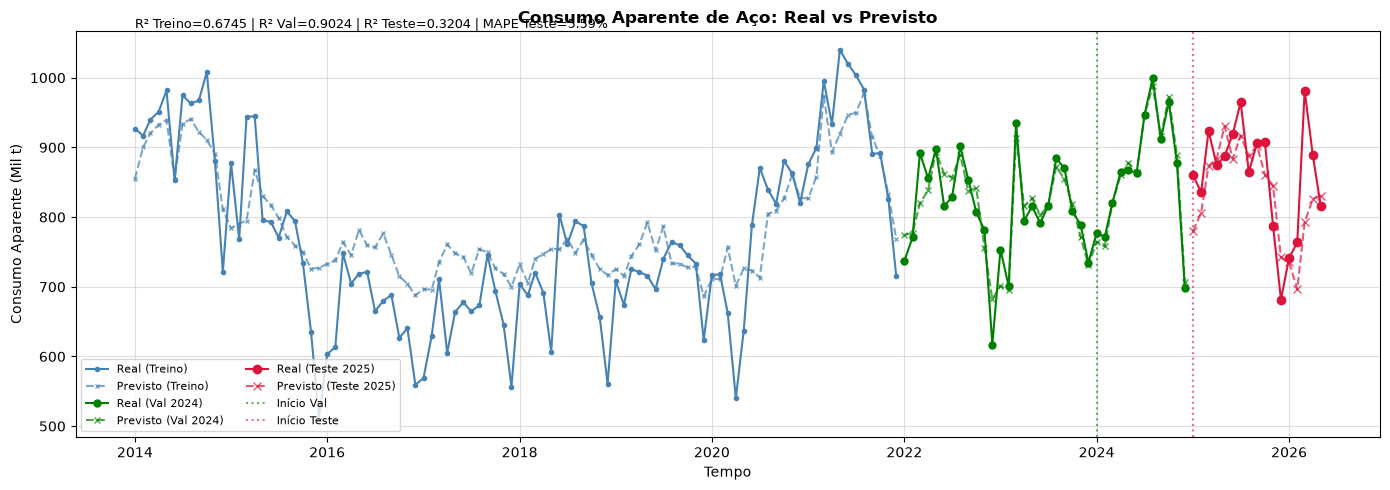

In [75]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_train['data'], y_train.values, label='Real (Treino)', marker='o', markersize=3, color='steelblue')
ax.plot(df_train['data'], y_pred_train_opt, label='Previsto (Treino)', linestyle='--', marker='x', markersize=3, color='steelblue', alpha=0.7)

ax.plot(df_val['data'], y_val.values, label='Real (Val 2024)', marker='o', markersize=5, color='green')
ax.plot(df_val['data'], y_pred_val_opt, label='Previsto (Val 2024)', linestyle='--', marker='x', markersize=5, color='green', alpha=0.7)

ax.plot(df_test['data'], y_test.values, label='Real (Teste 2025)', marker='o', markersize=6, color='crimson')
ax.plot(df_test['data'], y_pred_test_opt, label='Previsto (Teste 2025)', linestyle='--', marker='x', markersize=6, color='crimson', alpha=0.7)

ax.axvline(pd.Timestamp('2024-01-01'), color='green', linestyle=':', alpha=0.6, label='Início Val')
ax.axvline(pd.Timestamp('2025-01-01'), color='crimson', linestyle=':', alpha=0.6, label='Início Teste')

ax.set_title('Consumo Aparente de Aço: Real vs Previsto', fontsize=12, fontweight='bold')
ax.set_xlabel('Tempo')
ax.set_ylabel('Consumo Aparente (Mil t)')
ax.text(df_train['data'].iloc[0], y_train.max() * 1.03,
        f'R² Treino={r2_train_opt} | R² Val={r2_val_opt} | R² Teste={r2_test_opt} | MAPE Teste={mape_test_opt:.2%}',
        fontsize=9)
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig(f'./{path_secao_atual}/real_x_predito_r2_train_{r2_train_opt}_r2_test_{r2_test_opt}.png', bbox_inches='tight')

# Importância das variáveis

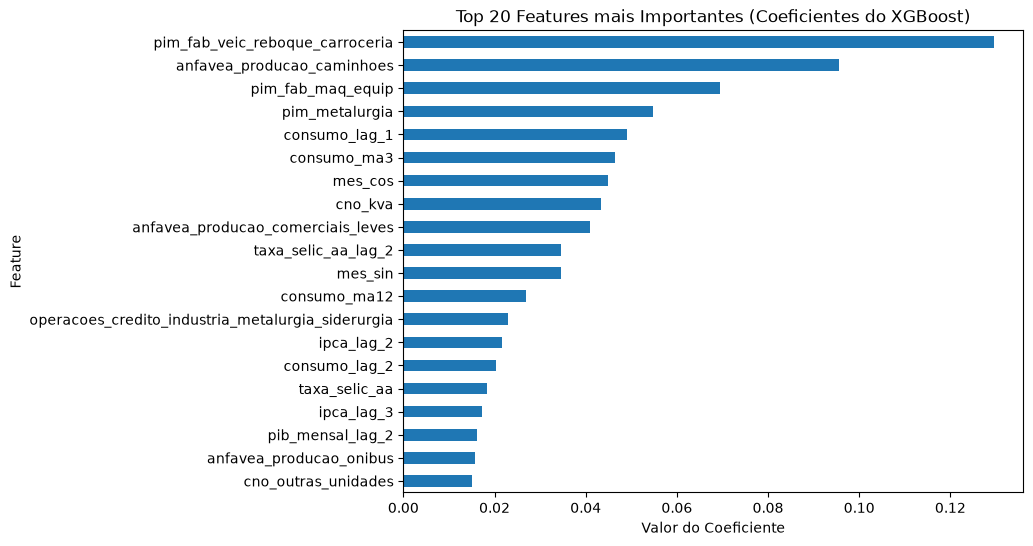

In [76]:
coefs = pd.Series(best_model.feature_importances_, index=best_model.feature_names_in_)

plt.figure(figsize=(8, 6))
coefs.sort_values(key=abs, ascending=True).tail(20).plot(kind='barh')
plt.title('Top 20 Features mais Importantes (Coeficientes do XGBoost)')
plt.xlabel('Valor do Coeficiente')
plt.ylabel('Feature')
plt.savefig(f'./{path_secao_atual}/top_20_features_r2_train_{r2_train_opt}_r2_test_{r2_test_opt}.png', bbox_inches='tight')

# Salvar modelo

In [77]:
os.makedirs('./Modelos', exist_ok=True)
best_model_name = type(best_model).__name__
pickle.dump(best_model, open(f'./{path_secao_atual}/{best_model_name}_r2_train_{r2_train_opt}_r2_test_{r2_test_opt}.pkl', 'wb'))

# Salvar dados utilizados na execução

In [78]:
df_valid_data = pd.concat([
    X_train.assign(y_real=y_train.values, y_pred=y_pred_train_opt, split='train'),
    X_val.assign(y_real=y_val.values,     y_pred=y_pred_val_opt,   split='val'),
    X_test.assign(y_real=y_test.values,   y_pred=y_pred_test_opt,  split='test'),
]).reset_index(drop=True)

df_valid_data.to_excel(
    f'./{path_secao_atual}/valid_data_{best_model_name}_r2_train_{r2_train_opt}_r2_test_{r2_test_opt}.xlsx',
    index=False, engine='openpyxl'
)

In [79]:
df_valid_data.head()

,consumo_lag_1,consumo_ma3,consumo_ma6,pim_fab_maq_equip,pim_fab_veic_reboque_carroceria,consumo_lag_2,anfavea_producao_caminhoes,consumo_ma12,anfavea_producao_comerciais_leves,consumo_lag_3,anfavea_producao_onibus,operacoes_credito_industria_metalurgia_siderurgia,pib_mensal,anfavea_producao_autoveiculos_total,pib_mensal_lag_1,mes_cos,pib_mensal_lag_3,pib_mensal_lag_2,ipca_lag_1,ipca_lag_3,pim_metalurgia,taxa_selic_aa_lag_3,ipca,trend,cno_outras_unidades,taxa_selic_aa_lag_2,operacoes_credito_industria_construcao,ipca_lag_2,pim_fab_outros_equip_transporte,taxa_selic_aa_lag_1,mes_sin,cno_m3,valor_cambio_reais,cno_kva,taxa_selic_aa,cno_kw,cno_km,cno_m2,y_real,y_pred,split
0,769.865,949.954333,1005.247667,660.4378,967.89891,995.462,13776,991.862417,30088,1084.536,2431,48880,453274.2,237390,467254.2,8.660254e-01,475720.9,470316.1,0.92,0.57,1598.927,10.164934,0.55,12,5.273980e+05,8.990490,107896,0.54,1304.52774,9.902948,0.500000,67046.35,1.690171,150.0,10.690623,0.00,13224.64,7793517.45,927.046,855.144104,train
1,927.046,897.457667,979.529833,660.4378,967.89891,769.865,15174,993.624917,39125,995.462,3750,49258,455505.4,281627,453274.2,5.000000e-01,470316.1,467254.2,0.55,0.54,1598.927,8.990490,0.69,13,1.882174e+06,9.902948,108950,0.92,1304.52774,10.690623,0.866025,14043.68,1.702207,0.0,9.902948,60000.00,12370.35,4172578.38,916.842,900.387268,train
2,916.842,871.251000,954.759500,660.4378,967.89891,927.046,13844,997.158583,36211,769.865,3700,49832,477201.5,272754,455505.4,6.123234e-17,467254.2,453274.2,0.69,0.92,1598.927,9.902948,0.92,14,1.281491e+08,10.690623,110130,0.55,1304.52774,9.902948,1.000000,341809.82,1.425303,500.0,9.641534,51050.17,27611.11,3919601.95,940.044,920.458984,train
3,940.044,927.977333,938.965833,660.4378,967.89891,916.842,12314,990.581250,42551,927.046,3395,49751,479725.1,277091,477201.5,-5.000000e-01,453274.2,455505.4,0.92,0.55,1598.927,10.690623,0.67,15,2.380034e+06,9.902948,111799,0.69,1304.52774,9.641534,0.866025,30289.10,1.488117,0.0,10.296141,56000.00,63868.05,5182198.92,951.105,932.670105,train
4,951.105,935.997000,916.727333,660.4378,967.89891,940.044,12695,983.580083,40144,916.842,3388,49331,481271.5,281355,479725.1,-8.660254e-01,455505.4,477201.5,0.67,0.69,1598.927,9.902948,0.46,16,2.394161e+06,9.641534,113783,0.92,1304.52774,10.296141,0.500000,308819.95,1.504061,0.0,10.954329,0.00,79957.55,5714652.20,981.738,939.347168,train


In [80]:
df_valid_data.shape

(149, 41)

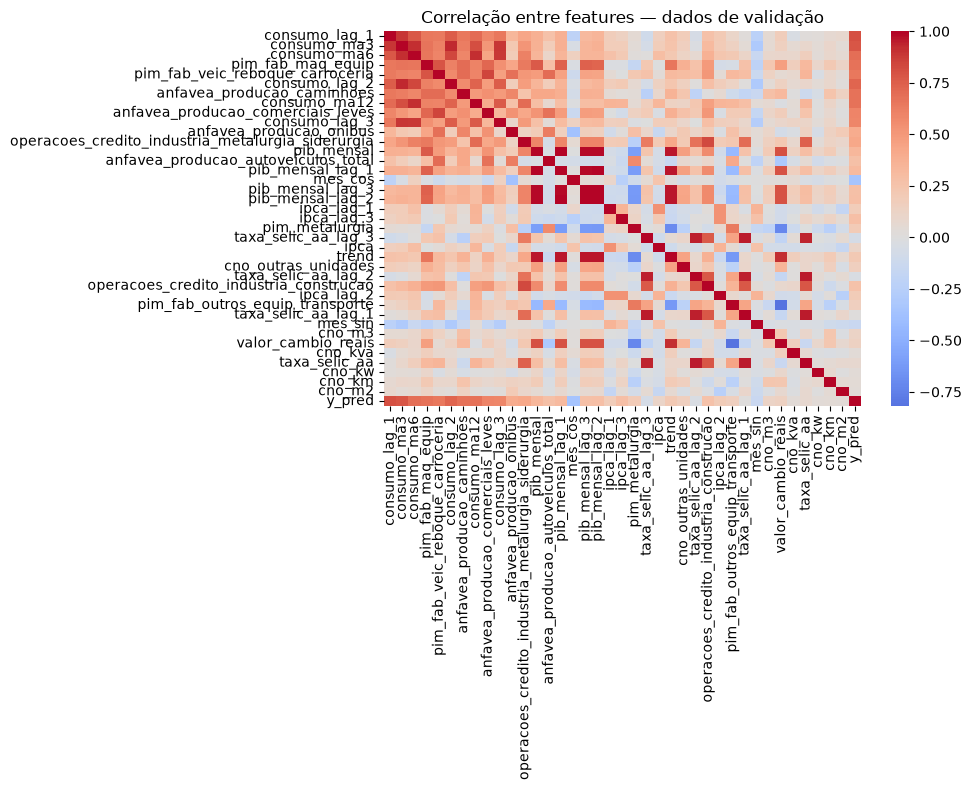

In [81]:
numeric_valid = df_valid_data.select_dtypes(include='number').drop(columns=['y_real'], errors='ignore')
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_valid.corr(), annot=False, cmap='coolwarm', center=0)
plt.title('Correlação entre features — dados de validação')
plt.tight_layout()
plt.savefig(f'./{path_secao_atual}/correlation_matrix_{r2_train_opt}_r2_test_{r2_test_opt}.png', bbox_inches='tight')

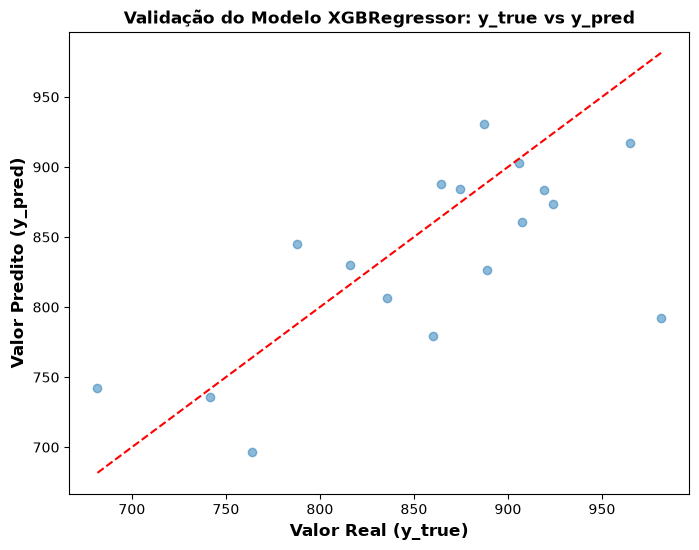

In [82]:
plt.figure(figsize=(8,6))
plt.scatter(y_test.values, y_pred_test_opt, alpha=0.5)
min_val = min(np.min(y_test.values), np.min(y_pred_test_opt))
max_val = max(np.max(y_test.values), np.max(y_pred_test_opt))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')
plt.xlabel('Valor Real (y_true)', fontsize=12, fontweight='bold')
plt.ylabel('Valor Predito (y_pred)', fontsize=12, fontweight='bold')
plt.title(f'Validação do Modelo {best_model_name}: y_true vs y_pred', fontsize=12, fontweight='bold')
plt.savefig(f'./{path_secao_atual}/dispersion_y_true_x_y_pred_{r2_train_opt}_r2_test_{r2_test_opt}.png', bbox_inches='tight')

# Análise de Resíduos — XGBoost


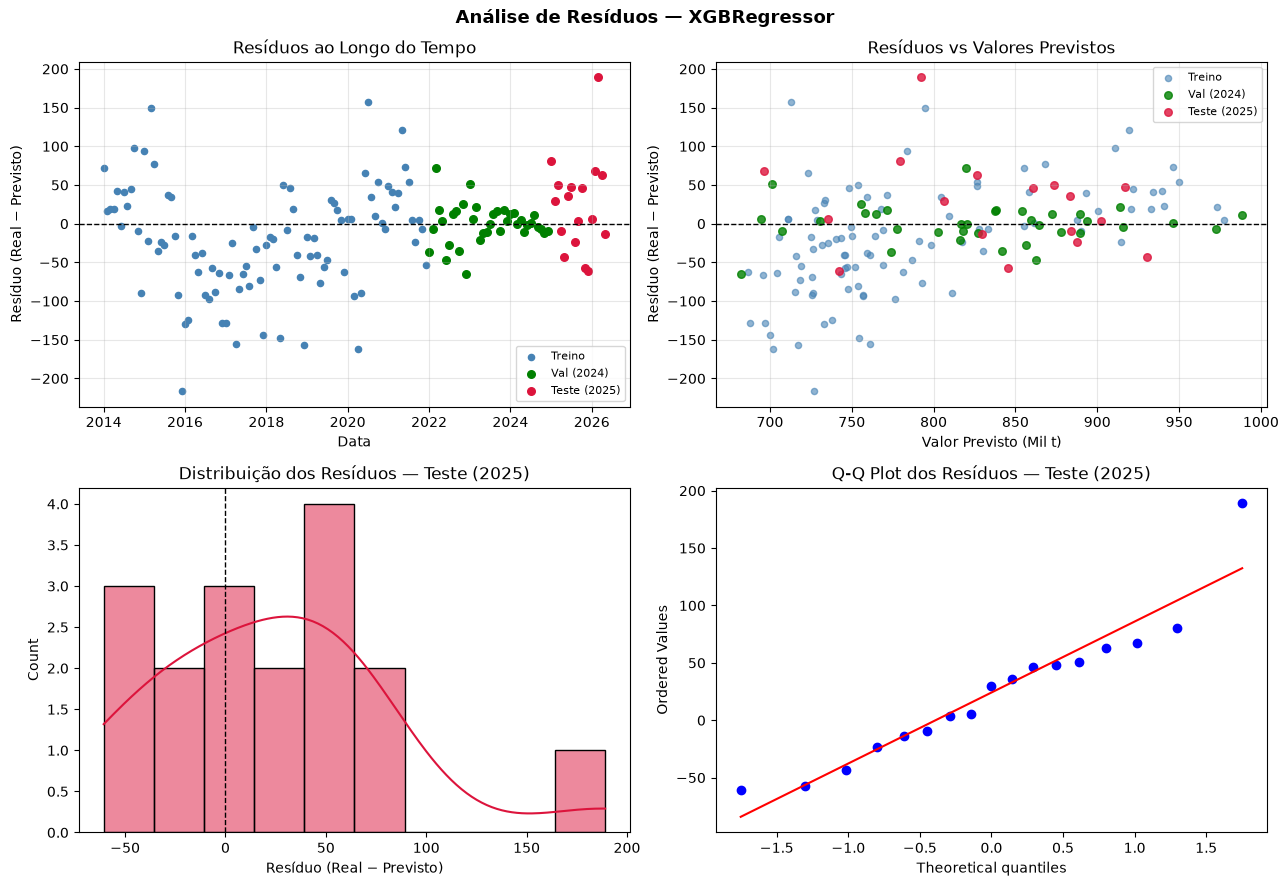

In [83]:
# Resíduos = valor real - valor previsto
residuos_train = y_train.values - y_pred_train_opt
residuos_val   = y_val.values   - y_pred_val_opt
residuos_test  = y_test.values  - y_pred_test_opt

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# 1. Resíduos ao longo do tempo
ax = axes[0, 0]
ax.scatter(df_train['data'], residuos_train, label='Treino', color='steelblue', s=20)
ax.scatter(df_val['data'],   residuos_val,   label='Val (2024)',   color='green',   s=30)
ax.scatter(df_test['data'],  residuos_test,  label='Teste (2025)', color='crimson', s=30)
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_title('Resíduos ao Longo do Tempo')
ax.set_xlabel('Data')
ax.set_ylabel('Resíduo (Real − Previsto)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# 2. Resíduos vs valores previstos — checa heterocedasticidade
ax = axes[0, 1]
ax.scatter(y_pred_train_opt, residuos_train, label='Treino', color='steelblue', s=20, alpha=0.6)
ax.scatter(y_pred_val_opt,   residuos_val,   label='Val (2024)',   color='green',   s=30, alpha=0.8)
ax.scatter(y_pred_test_opt,  residuos_test,  label='Teste (2025)', color='crimson', s=30, alpha=0.8)
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_title('Resíduos vs Valores Previstos')
ax.set_xlabel('Valor Previsto (Mil t)')
ax.set_ylabel('Resíduo (Real − Previsto)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# 3. Histograma dos resíduos (teste)
ax = axes[1, 0]
sns.histplot(residuos_test, kde=True, bins=10, color='crimson', ax=ax)
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_title('Distribuição dos Resíduos — Teste (2025)')
ax.set_xlabel('Resíduo (Real − Previsto)')

# 4. Q-Q plot dos resíduos (teste) — checa normalidade
from scipy import stats
ax = axes[1, 1]
stats.probplot(residuos_test, dist='norm', plot=ax)
ax.set_title('Q-Q Plot dos Resíduos — Teste (2025)')

fig.suptitle(f'Análise de Resíduos — {best_model_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(
    f'./{path_secao_atual}/residuos_xgboost_r2_train_{r2_train_opt}_r2_test_{r2_test_opt}.png',
    bbox_inches='tight')
